# WHOMOLLM Project
## Geo context prompt (Version 3) 03.Feb.2026
### We try to keep the baseline based on the paper (Wu, et al., 2019), do the feature engineering.
1. Raw data
2. stay segmentation
3. reverse geocoding
4. top 5 POIs aggregation
5. semantic stay table
6. LLM prompt (daily narrative/ activity inference/ other surplus info)

## 1. Test GPU, model 

In [1]:
import os, json, re, subprocess, sys
import torch
import requests
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    p = torch.cuda.get_device_properties(0)
    print("VRAM (GB):", round(p.total_memory/1024**3, 2))

# Check ollama is reachable
r = requests.get("http://127.0.0.1:11434/api/tags", timeout=3)
print("Ollama OK. Models:", [m["name"] for m in r.json().get("models",[])])

KeyboardInterrupt: 

## 2. Generate prompts (3nd version with just geo context information and behaviour info, predict household size and household income level ... for all users)
Version control:
This is the basic prompt based on geocontext and behaviour info, version 3.

In [3]:
#   ---------------------------
# Version 3 (28 Jan 2026) prompt with geo context to predict features
#   ---------------------------

import os, re, json
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import pdb

# ---------------------------
# Config
# ---------------------------
RANDOM_SEED = 42
N_USERS     = 5
MAX_EVENTS  = 300
HOUR_BIN    = 1
PREC        = int(os.getenv("COORD_PREC", "4"))


DATA_SP     = Path("/data/baliu/python_code/data/sp_all copy.csv")
PROMPTS_OUT = Path("/data/baliu/python_code/data/prompts_v3_features_28Jan2026.json")

# -------------------------------------------   
# Load (strings) + base cleaning
# -------------------------------------------
sp = pd.read_csv(DATA_SP, dtype=str, engine="python", on_bad_lines="skip")
print("sp shape:", sp.shape)
# print("sp columns:", sp.columns.tolist())

# Datetimes
sp["started_at"]  = pd.to_datetime(sp["started_at"], errors="coerce", utc=True)
sp["finished_at"] = pd.to_datetime(sp.get("finished_at"), errors="coerce", utc=True)

# Drop unusable
sp = sp.dropna(subset=["user_id", "started_at", "location_id"]).copy()
sp["user_id"]     = sp["user_id"].astype(str)
sp["location_id"] = sp["location_id"].astype(str)

#sp["duration_min"] = ((sp["finished_at"] - sp["started_at"]).dt.total_seconds() / 60.0).astype(float)
print(sp["duration"].head())
print(sp["duration"].dtype)

# Force numeric
sp["act_duration"] = pd.to_numeric(
    sp["act_duration"],
    errors="coerce"
)

# change it to hours
sp["act_duration_h"] = (sp["act_duration"] / 60.0).round(1)
print(sp["act_duration_h"].head())
print(sp["act_duration_h"].dtype)

# length_km: convert to numeric, coerce errors to NaN, then divide by 1000
sp["length_km"] = pd.to_numeric(sp["length"], errors="coerce") / 1000.0
sp["length_km"] = sp["length_km"].round(1)

# Time features
sp["date"]     = sp["started_at"].dt.date
sp["dow"]      = sp["started_at"].dt.dayofweek.astype(int)        # 0=Mon
sp["hour_bin"] = (sp["started_at"].dt.hour // HOUR_BIN * HOUR_BIN).astype(int)

# ---------------------------
# Format from wkt point -> lon/lat (rounded)
# ---------------------------
WKT_POINT_RE = re.compile(
    r"POINT\s*\(\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s+([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*\)",
    re.I,
)

def extract_lonlat_from_wkt(s: str):
    m = WKT_POINT_RE.search(str(s))
    if not m: return (np.nan, np.nan)
    return float(m.group(1)), float(m.group(2))

sp["geometry"] = sp.get("geometry", pd.Series(index=sp.index)).astype(str)
lonlat = sp["geometry"].apply(extract_lonlat_from_wkt)
sp[["lon","lat"]] = pd.DataFrame(lonlat.tolist(), index=sp.index)
sp["lon"] = pd.to_numeric(sp["lon"], errors="coerce").round(PREC)
sp["lat"] = pd.to_numeric(sp["lat"], errors="coerce").round(PREC)

# Lightweight tags
sp["geometry_type"] = np.where(sp["lon"].notna() & sp["lat"].notna(), "point", "-")
if "mode" not in sp.columns: sp["mode"] = "-"

sp shape: (1152987, 10)
0    1093.0
1      39.0
2      75.0
3     164.0
4      36.0
Name: duration, dtype: object
object
0    18.2
1     1.2
2     1.4
3     5.6
4     1.2
Name: act_duration_h, dtype: float64
float64


In [4]:
print(sp["act_duration_h"].head())
print(sp["act_duration_h"].dtype)
print(sp["length_km"].head())
print(sp["length_km"].dtype)

0    18.2
1     1.2
2     1.4
3     5.6
4     1.2
Name: act_duration_h, dtype: float64
float64
0     0.0
1    11.6
2     2.1
3     4.8
4    12.6
Name: length_km, dtype: float64
float64


In [5]:
print ("sp after cleaning:", sp.shape)
print (sp.head(5))

sp after cleaning: (862871, 18)
  id user_id                       started_at  \
0  0   AAGAF 2019-10-09 11:30:34.141000+00:00   
1  1   AAGAF 2019-10-10 06:14:49.141999+00:00   
2  2   AAGAF 2019-10-10 07:03:24.426000+00:00   
3  3   AAGAF 2019-10-10 11:10:24.605999+00:00   
4  4   AAGAF 2019-10-10 14:30:45.187999+00:00   

                       finished_at location_id  mode              length  \
0 2019-10-10 05:43:17.674999+00:00           0   Car                 0.0   
1 2019-10-10 06:53:54.841000+00:00           1   Car  11615.408548376423   
2 2019-10-10 08:18:20.864000+00:00           2   Car  2104.8558581266784   
3 2019-10-10 13:54:34.799339+00:00           2  Walk   4847.706521391238   
4 2019-10-10 15:07:07.127239+00:00           3   Car  12621.909934521313   

                                       geometry duration  act_duration  \
0  POINT (7.565219245342489 47.545616372908086)   1093.0        1093.0   
1  POINT (7.5637597959179645 47.54794767256367)     39.0          71

In [6]:
# ---------------------------
# Sample 1 week per user
# ---------------------------
def sample_one_week_per_user(sp, seed=42):
    rng = np.random.default_rng(seed)
    sp = sp.copy()
    sp["date"] = pd.to_datetime(sp["date"])

    out = []
    for uid, df_u in sp.groupby("user_id"):
        days = (
            df_u[["date"]]
            .drop_duplicates()
            .sort_values("date")
            .reset_index(drop=True)
        )

        if len(days) < 7:
            continue
        days["delta"] = days["date"].diff().dt.days.fillna(1).astype(int)
        days["block"] = (days["delta"] >1).cumsum()

        valid_blocks = (
            days.groupby("block")
            .filter(lambda x: len(x) >=7)
        )

        if valid_blocks.empty:
            continue
        candidate_starts = []
        for _, g in valid_blocks.groupby("block"):
            block_dates = g["date"].sort_values().reset_index(drop=True)
            for i in range(len(block_dates) - 6):
                candidate_starts.append(g.iloc[i]["date"])

        start_date = rng.choice(candidate_starts)
        week_dates = pd.date_range(start=start_date, periods=7, freq= 'D')

        out.append(
            df_u[df_u["date"].isin(week_dates)]

        )
       
    return pd.concat(out, ignore_index=True)

sp_sampled2 = sample_one_week_per_user(sp, seed=RANDOM_SEED)
print("sp_sampled2 shape:", sp_sampled2.shape)
print(sp_sampled2.head(2))

# ---------------------------
# save sampled data
# ---------------------------
SP_SAMPLED2_OUT = Path("/data/baliu/python_code/data/sp_sampled2_1week_28Jan2026.csv")
sp_sampled2.to_csv(SP_SAMPLED2_OUT, index=False)
print("Saved sp_sampled2_1week_28Jan2026 to", SP_SAMPLED2_OUT)  

sp_sampled2 shape: (60738, 18)
   id user_id                       started_at  \
0  23   AAGAF 2019-10-22 09:39:28.773999+00:00   
1  24   AAGAF 2019-10-23 06:35:32.236999+00:00   

                       finished_at location_id  mode             length  \
0 2019-10-23 03:56:33.583344+00:00          10   Bus  3823.055092733663   
1 2019-10-23 08:31:59.036438+00:00          16  Tram  8232.492568529495   

                                       geometry duration  act_duration  \
0  POINT (7.564359990583688 47.546459921667946)   1097.0        6456.0   
1   POINT (7.603269084785703 47.58100341208616)    116.0         275.0   

   act_duration_h  length_km       date  dow  hour_bin     lon      lat  \
0           107.6        3.8 2019-10-22    1         9  7.5644  47.5465   
1             4.6        8.2 2019-10-23    2         6  7.6033  47.5810   

  geometry_type  
0         point  
1         point  
Saved sp_sampled2_1week_28Jan2026 to /data/baliu/python_code/data/sp_sampled2_1week_28Jan

#### Load location name and POIs top 5

In [7]:
# 1. Load toponym data from shepefiles
import os, re, json
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import pdb
import geopandas as gpd
import fiona
# read parquet file
import pyarrow.parquet as pq
 
CACHE_DIR   = Path("/data/baliu/python_code/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
NOM_CACHE_PATH = CACHE_DIR / "nominatim_cache.parquet"
nom = pd.read_parquet(NOM_CACHE_PATH)
print("Nominatim cache loaded:", nom.shape)
print("Nominatim columns:", nom.columns.tolist())
nom.head(30)
groupby_category = nom.groupby('city').size()
print(groupby_category) 

Nominatim cache loaded: (370983, 6)
Nominatim columns: ['lon', 'lat', 'road', 'neighbourhood', 'city', 'postcode']
city
A Coruña                 2
A Illa de Arousa         2
A Pobra do Caramiñal     7
A Seara                  1
Aachen                   2
                        ..
دهستان سروستان           1
دهستان فجر               3
دهستان کرکس              1
บ้านอ่าวน้ำเมา           1
เทศบาลนครเกาะสมุย       55
Length: 7400, dtype: int64


In [8]:
from notebook_utils.geocontext import attach_nominatim, clean_nominatim_fields

sp_sampled2 = attach_nominatim(sp_sampled2, nom)
sp_sampled2 = clean_nominatim_fields(sp_sampled2)
print("sp_sampled2 after attaching nominatim:", sp_sampled2.shape)
print("sp_sampled2 columns:", sp_sampled2.columns.tolist())
print(sp_sampled2.head(10))


sp_sampled2 after attaching nominatim: (60738, 22)
sp_sampled2 columns: ['id', 'user_id', 'started_at', 'finished_at', 'location_id', 'mode', 'length', 'geometry', 'duration', 'act_duration', 'act_duration_h', 'length_km', 'date', 'dow', 'hour_bin', 'lon', 'lat', 'geometry_type', 'road', 'neighbourhood', 'city', 'postcode']
   id user_id                       started_at  \
0  23   AAGAF 2019-10-22 09:39:28.773999+00:00   
1  24   AAGAF 2019-10-23 06:35:32.236999+00:00   
2  25   AAGAF 2019-10-23 09:02:58.773999+00:00   
3  26   AAGAF 2019-10-23 09:53:18.151999+00:00   
4  27   AAGAF 2019-10-23 16:44:43.608999+00:00   
5  28   AAGAF 2019-10-24 06:05:44.141999+00:00   
6  29   AAGAF 2019-10-24 07:22:44.510999+00:00   
7  30   AAGAF 2019-10-24 09:55:47.243000+00:00   
8  31   AAGAF 2019-10-24 13:05:05.668999+00:00   
9  32   AAGAF 2019-10-24 15:03:21.792999+00:00   

                       finished_at location_id  mode              length  \
0 2019-10-23 03:56:33.583344+00:00          10 

#### Build token with geocontext info

In [9]:
from pathlib import Path
from notebook_utils.geocontext import load_poi_frame

POI_PATH = Path("/data/baliu/python_code/data/version2/data/final_pois_nob.gpkg")
poi = load_poi_frame(POI_PATH)
pois = poi
poi.head()


,id,code,name,category,geometry
0,0,3100,Temple de Saint-Jean,Civic,POINT (2498816.948 1117839.539)
1,1,3100,Kapelle Oberes Heiliges Kreuz,Civic,POINT (2691857.357 1192677.631)
2,2,3102,Kirche St. Johannes,Civic,POINT (2599659.594 1202970.041)
3,3,3102,Paroisse catholique,Civic,POINT (2501879.911 1126418.086)
4,4,3300,Mosquée du Petit-Saconnex,Civic,POINT (2498411.634 1119984.893)


In [10]:
poi = poi.copy()
print(poi["category"].value_counts())
print(f"poi crs: {poi.crs}")


category
Others            158579
Unknown           114894
Entertainment     106734
Shopping           54634
Residential        45556
Transportation     40997
Services            9525
Schools             2904
Civic                780
Name: count, dtype: int64
poi crs: EPSG:2056


In [11]:
from notebook_utils.geocontext import load_poi_frame

def load_pois_once():
    global poi
    if poi is None:
        print("Loading POIs into memory...")
        poi = load_poi_frame(POI_PATH)
    return poi

print(poi.head(2))


   id  code                           name category  \
0   0  3100           Temple de Saint-Jean    Civic   
1   1  3100  Kapelle Oberes Heiliges Kreuz    Civic   

                          geometry  
0  POINT (2498816.948 1117839.539)  
1  POINT (2691857.357 1192677.631)  


In [12]:
from notebook_utils.geocontext import build_location_gdf

loc = build_location_gdf(sp_sampled2)


### update the table with places name and pois

update

In [13]:
# update: 
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial import cKDTree

def bearing_to_direction(dx, dy):
    angle = np.degrees(np.arctan2(dx, dy))
    angle = (angle + 360) % 360

    if 22.5 <= angle < 67.5:
        return "North-East"
    elif 67.5 <= angle < 112.5:
        return "East"
    elif 112.5 <= angle < 157.5:
        return "South-East"
    elif 157.5 <= angle < 202.5:
        return "South"
    elif 202.5 <= angle < 247.5:
        return "South-West"
    elif 247.5 <= angle < 292.5:
        return "West"
    elif 292.5 <= angle < 337.5:
        return "North-West"
    else:
        return "North"

def get_poi_context_for_prompt(sp_sampled2, poi, top_k=5):

    # ---- prepare GeoDataFrames ----
    loc = gpd.GeoDataFrame(
        sp_sampled2.copy(),
        geometry=gpd.points_from_xy(
            sp_sampled2["lon"].astype(float),
            sp_sampled2["lat"].astype(float)
        ),
        crs="EPSG:4326"
    ).to_crs(2056)

    poi = poi.copy().set_crs(epsg=2056, allow_override=True)

    # ---- KDTree on POIs ----
    poi_xy = np.c_[poi.geometry.x.values, poi.geometry.y.values]
    tree = cKDTree(poi_xy)

    loc_xy = np.c_[loc.geometry.x.values, loc.geometry.y.values]
    dists, idxs = tree.query(loc_xy, k=top_k * 5) # get more to filter later

    # ---- build kNN table ----
    rows = []
    for i, (ds, js) in enumerate(zip(dists, idxs)):
        for d, j in zip(ds, js):
            rows.append({
                "location_id": loc.iloc[i]["location_id"],
                "name": poi.iloc[j]["name"],
                "category": poi.iloc[j]["category"],
                "addr_poi_dist_m": d,
                "dx": poi.geometry.iloc[j].x - loc.geometry.iloc[i].x,
                "dy": poi.geometry.iloc[j].y - loc.geometry.iloc[i].y
            })

    joined = pd.DataFrame(rows)

    # ---- clean categories ----
    joined = joined[
        joined["category"].notna() &
        (~joined["category"].str.lower().isin(["unknown", "others"]))
    ]

    # ---- distance + direction ----
    joined["addr_poi_dist_km"] = (joined["addr_poi_dist_m"] / 1000).round(3)
    joined["direction"] = [
        bearing_to_direction(dx, dy)
        for dx, dy in zip(joined.dx, joined.dy)
    ]
    
    joined = (
        joined
        .sort_values("addr_poi_dist_m")
        .groupby("location_id", group_keys=False)
        .head(top_k)
    )

    return joined[
        ["location_id", "name", "category", "addr_poi_dist_km", "direction"]
    ]

def clean_text_part(s):
    if pd.isna(s):
        return None
    s = str(s).strip()
    if s.lower() in ["none", "nan", "-", ""]:
        return None
    return s

def build_poi_prompt_text(df):
    out = []
    for _, r in df.iterrows():
        dist = r["addr_poi_dist_km"]
        direction = r["direction"].lower()
        
       
        category = clean_text_part(r.get("category")) or "point of interest"
        name = clean_text_part(r.get("name"))

        if name:
            poi_desc = f"{category} {name}"
        else:
            poi_desc = f"{category}"
        out.append(
            f"{dist} km to the {direction}: {poi_desc}"
        )
    return out

poi_prompt_df = (
    get_poi_context_for_prompt(sp_sampled2, poi, top_k=5)
    .groupby("location_id", group_keys=False)
    .apply(build_poi_prompt_text, include_groups=False)
    .reset_index(name="nearby_places")
)

sp_sampled2 = sp_sampled2.merge(
    poi_prompt_df,
    on="location_id",
    how="left"
)
print(
    get_poi_context_for_prompt(sp_sampled2, poi)
    ["addr_poi_dist_km"]
    .describe()
)

from pathlib import Path

SP_SAMPLED2_OUT = Path("/data/baliu/python_code/data/sp_sampled2_v3_1week_29Jan2026_with_geocontext.csv")
sp_sampled2.to_csv(SP_SAMPLED2_OUT, index=False)

print("Saved sp_sampled2 to", SP_SAMPLED2_OUT)
print(sp_sampled2.head(5))

count    116301.000000
mean        288.675402
std        1458.250814
min           0.000000
25%           0.042000
50%           0.101000
75%           0.262000
max       14837.215000
Name: addr_poi_dist_km, dtype: float64
Saved sp_sampled2 to /data/baliu/python_code/data/sp_sampled2_v3_1week_29Jan2026_with_geocontext.csv
   id user_id                       started_at  \
0  23   AAGAF 2019-10-22 09:39:28.773999+00:00   
1  24   AAGAF 2019-10-23 06:35:32.236999+00:00   
2  25   AAGAF 2019-10-23 09:02:58.773999+00:00   
3  26   AAGAF 2019-10-23 09:53:18.151999+00:00   
4  27   AAGAF 2019-10-23 16:44:43.608999+00:00   

                       finished_at location_id  mode              length  \
0 2019-10-23 03:56:33.583344+00:00          10   Bus   3823.055092733663   
1 2019-10-23 08:31:59.036438+00:00          16  Tram   8232.492568529495   
2 2019-10-23 09:38:13.596999+00:00          17  Walk   2892.684874565825   
3 2019-10-23 16:19:19.816718+00:00          10   Car  3283.143616000176

In [ ]:
# update: 
import numpy as np

def bearing_to_direction(dx, dy):
    angle = np.degrees(np.arctan2(dx, dy))
    angle = (angle + 360) % 360

    if 22.5 <= angle < 67.5:
        return "North-East"
    elif 67.5 <= angle < 112.5:
        return "East"
    elif 112.5 <= angle < 157.5:
        return "South-East"
    elif 157.5 <= angle < 202.5:
        return "South"
    elif 202.5 <= angle < 247.5:
        return "South-West"
    elif 247.5 <= angle < 292.5:
        return "West"
    elif 292.5 <= angle < 337.5:
        return "North-West"
    else:
        return "North"

import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial import cKDTree

def get_poi_context_for_prompt(sp_sampled2, poi, top_k=5):

    # ---- prepare GeoDataFrames ----
    loc = gpd.GeoDataFrame(
        sp_sampled2.copy(),
        geometry=gpd.points_from_xy(
            sp_sampled2["lon"].astype(float),
            sp_sampled2["lat"].astype(float)
        ),
        crs="EPSG:4326"
    ).to_crs(2056)

    poi = poi.copy().set_crs(epsg=2056, allow_override=True)

    # ---- KDTree on pois ----
    poi_xy = np.c_[poi.geometry.x.values, poi.geometry.y.values]
    tree = cKDTree(poi_xy)

    loc_xy = np.c_[loc.geometry.x.values, loc.geometry.y.values]
    dists, idxs = tree.query(loc_xy, k=top_k * 3) # get more to filter later

    # ---- build kNN table ----
    rows = []
    for i, (ds, js) in enumerate(zip(dists, idxs)):
        for d, j in zip(ds, js):
            rows.append({
                "location_id": loc.iloc[i]["location_id"],
                "name": poi.iloc[j]["name"],
                "category": poi.iloc[j]["category"],
                "addr_poi_dist_m": d,
                "dx": poi.geometry.iloc[j].x - loc.geometry.iloc[i].x,
                "dy": poi.geometry.iloc[j].y - loc.geometry.iloc[i].y
            })

    joined = pd.DataFrame(rows)

    # ---- clean categories ----
    joined = joined[
        joined["category"].notna() &
        (~joined["category"].str.lower().isin(["unknown", "others"]))
    ]

    # ---- distance + direction ----
    joined["addr_poi_dist_km"] = (joined["addr_poi_dist_m"] / 1000).round(3)
    joined["direction"] = [
        bearing_to_direction(dx, dy)
        for dx, dy in zip(joined.dx, joined.dy)
    ]
    
    joined = (
        joined
        .sort_values("addr_poi_dist_m")
        .groupby("location_id", group_keys=False)
        .head(top_k)
    )

    return joined[
        ["location_id", "name", "category", "addr_poi_dist_km", "direction"]
    ]

def build_poi_prompt_text(df):
    out = []
    for _, r in df.iterrows():
        name = r["name"] if pd.notna(r["name"]) else "unknown place"
        category = r["category"] if pd.notna(r["category"]) else "point of interest"
        out.append(
            f"{r['addr_poi_dist_km']} km to the {r['direction'].lower()}: {category} {name}"
        )
    return "; ".join(out)

poi_prompt_df = (
    get_poi_context_for_prompt(sp_sampled2, poi, top_k=5)
    .groupby("location_id", group_keys=False)
    .apply(build_poi_prompt_text, include_groups=False)
    .reset_index(name="nearby_places")
)

sp_sampled2 = sp_sampled2.merge(
    poi_prompt_df,
    on="location_id",
    how="left"
)
print(
    get_poi_context_for_prompt(sp_sampled2, poi)
    ["addr_poi_dist_km"]
    .describe()
)

print("nearby_places in columns",
      "nearby_places" in sp_sampled2.columns)

print(
    sp_sampled2["nearby_places"]
    .notna()
    .value_counts(dropna=False)
)

print(sp_sampled2[["location_id", "nearby_places"]].head(5))


from pathlib import Path

SP_SAMPLED2_OUT = Path("/data/baliu/python_code/data/sp_sampled2_v3_with_geocontext.csv")
sp_sampled2.to_csv(SP_SAMPLED2_OUT, index=False)

print("Saved sp_sampled2 to", SP_SAMPLED2_OUT)
print(sp_sampled2.head(5))

count    226778.000000
mean        296.192856
std        1476.196361
min           0.000000
25%           0.059000
50%           0.133000
75%           0.355000
max       14837.298000
Name: addr_poi_dist_km, dtype: float64
nearby_places in columns? True
nearby_places
True     60319
False      419
Name: count, dtype: int64
  location_id                                      nearby_places
0          10  0.004 km to the east: Shopping Tabaklädeli Neu...
1          16  0.086 km to the south-east: Shopping unknown p...
2          17  0.023 km to the west: Entertainment unknown pl...
3          10  0.004 km to the east: Shopping Tabaklädeli Neu...
4           4  1.748 km to the south-east: Entertainment Ökos...
Saved sp_sampled1 to /data/baliu/python_code/data/sp_sampled1_v3_with_geocontext.csv
   id user_id                       started_at  \
0  23   AAGAF 2019-10-22 09:39:28.773999+00:00   
1  24   AAGAF 2019-10-23 06:35:32.236999+00:00   
2  25   AAGAF 2019-10-23 09:02:58.773999+00:00   
3

same as above, upgraded 

In [14]:
from notebook_utils.geocontext import print_poi_feature_summary

print_poi_feature_summary(sp_sampled2)



Final sp_sampled2 with POI features:
Columns: ['id', 'user_id', 'started_at', 'finished_at', 'location_id', 'mode', 'length', 'geometry', 'duration', 'act_duration', 'act_duration_h', 'length_km', 'date', 'dow', 'hour_bin', 'lon', 'lat', 'geometry_type', 'road', 'neighbourhood', 'city', 'postcode', 'nearby_places']

Sample rows:
   id user_id                       started_at  \
0  23   AAGAF 2019-10-22 09:39:28.773999+00:00   
1  24   AAGAF 2019-10-23 06:35:32.236999+00:00   
2  25   AAGAF 2019-10-23 09:02:58.773999+00:00   
3  26   AAGAF 2019-10-23 09:53:18.151999+00:00   
4  27   AAGAF 2019-10-23 16:44:43.608999+00:00   

                       finished_at location_id  mode              length  \
0 2019-10-23 03:56:33.583344+00:00          10   Bus   3823.055092733663   
1 2019-10-23 08:31:59.036438+00:00          16  Tram   8232.492568529495   
2 2019-10-23 09:38:13.596999+00:00          17  Walk   2892.684874565825   
3 2019-10-23 16:19:19.816718+00:00          10   Car  3283.1436

Clean the prompts 

## Baseline_ Knn  and Random forest model 

 We have installed scikit-learn and upgrade this package and xgboost, then i just deleted the records

In [12]:
"""
Household income prediction from mobility data
Using KNN and random forest classifiers
"""

import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. Data loading and preprocessing 
# ============================================================================

def load_data(trace_file='/data/baliu/python_code/data/sp_sampled12_with_geocontext.csv', survey_file='/data/baliu/python_code/data/introSurvey_complete.csv'):
    trace_df = pd.read_csv(trace_file)
    print(f"Trace data shape: {trace_df.shape}")
    
    survey_df = pd.read_csv(survey_file)
    print(f"Survey data shape: {survey_df.shape}")
    
    return trace_df, survey_df


def categorize_income(income_value):
    """Categorize household income from survey text labels."""
    if pd.isna(income_value):
        return None

    s = str(income_value).strip().lower()

    if s == "prefer not to say":
        return None

    if "4 000 chf or less" in s or "4000 chf or less" in s:
        return "0_<4000"

    if "4 001 - 8 000 chf" in s:
        return "1_4001-8000"

    if "8 001 - 12 000 chf" in s:
        return "2_8001-12000"

    if "12 001 - 16 000 chf" in s:
        return "3_12001-16000"

    if "more than 16 000 chf" in s:
        return "4_>16001"

    return None


def preprocess_survey_data(survey_df):
    """Preprocess survey data and create income categories"""
    print("\nPreprocessing survey data...")

    survey_df['income_category'] = survey_df['income'].apply(categorize_income)
    survey_df = survey_df.dropna(subset=['income_category'])
    survey_df = survey_df[['participant_ID', 'income', 'income_category']]

    print("Income category distribution:")
    print(survey_df['income_category'].value_counts().sort_index())

    return survey_df


# ============================================================================
# 2. Feature engineering from mobility traces 
# ============================================================================

def extract_temporal_features(group):
    """Extract time-based features from mobility traces"""
    
    if 'start_at' in group.columns:
        group['started_at'] = pd.to_datetime(group['start_at'])
        group['finished_at'] = pd.to_datetime(group['end_at'])
    
    features = {}
    features['total_trips'] = len(group)
    
    if 'started_at' in group.columns:
        group['hour'] = group['started_at'].dt.hour
        group['day_of_week'] = group['started_at'].dt.dayofweek
        
        features['morning_peak_trips'] = ((group['hour'] >= 6) & (group['hour'] <= 9) & (group['day_of_week'] < 5)).sum()
        features['evening_peak_trips'] = ((group['hour'] >= 16) & (group['hour'] <= 19) & (group['day_of_week'] < 5)).sum()
        features['peak_trip_ratio'] = (features['morning_peak_trips'] + features['evening_peak_trips']) / max(features['total_trips'], 1)
        
        features['weekday_trips'] = (group['day_of_week'] < 5).sum()
        features['weekend_trips'] = (group['day_of_week'] >= 5).sum()
        features['weekend_trip_ratio'] = features['weekend_trips'] / max(features['total_trips'], 1)
        
        features['unique_hours'] = group['hour'].nunique()
        features['unique_days'] = group['started_at'].dt.date.nunique()
    
    return features


def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


def calculate_radius_of_gyration(group):
    if 'lon' in group.columns and 'lat' in group.columns and len(group) > 1:
        lat_mean = group['lat'].mean()
        lon_mean = group['lon'].mean()
        distances = group.apply(lambda row: haversine_distance(
            row['lat'], row['lon'], lat_mean, lon_mean), axis=1)
        return np.sqrt((distances**2).mean())
    return 0


def extract_spatial_features(group):
    """Extract location-based features from mobility traces"""   
    features = {}
    
    if 'distance' in group.columns:
        features['total_distance'] = group['distance'].sum()
        features['avg_distance'] = group['distance'].mean()
        features['max_distance'] = group['distance'].max()
        features['min_distance'] = group['distance'].min()
        features['std_distance'] = group['distance'].std() if len(group) > 1 else 0
        features['distance_range'] = features['max_distance'] - features['min_distance']
    
    if 'location_id' in group.columns:
        features['unique_locations'] = group['location_id'].nunique()
        features['location_entropy'] = calculate_entropy(group['location_id'].value_counts())
    
    if 'geometry' in group.columns and 'length_km' in group.columns:
        features['radius_of_gyration'] = calculate_radius_of_gyration(group)
    
    return features


def extract_mode_features(group):
    """Extract transportation mode features"""
    features = {}
    
    if 'mode' in group.columns:
        mode_counts = group['mode'].value_counts()
        total_trips = len(group)
        
        for mode in group['mode'].unique():
            features[f'mode_{mode}_count'] = mode_counts.get(mode, 0)
            features[f'mode_{mode}_ratio'] = mode_counts.get(mode, 0) / total_trips
        
        features['mode_diversity'] = group['mode'].nunique()
        features['mode_entropy'] = calculate_entropy(mode_counts)
        features['dominant_mode_ratio'] = mode_counts.max() / total_trips
    
    return features


def calculate_entropy(value_counts):
    """Calculate Shannon entropy for diversity measure"""
    probabilities = value_counts / value_counts.sum()
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
    return entropy


def build_features_per_user(trace_df):
    """Build comprehensive feature set for each user"""
    print("\nBuilding features from mobility traces...")
    
    all_features = []
    
    for user_id, user_group in trace_df.groupby('user_id'):
        user_features = {'user_id': user_id}
        
        temporal_features = extract_temporal_features(user_group)
        spatial_features = extract_spatial_features(user_group)
        mode_features = extract_mode_features(user_group)
        
        user_features.update(temporal_features)
        user_features.update(spatial_features)
        user_features.update(mode_features)
        
        if 'total_trips' in user_features and 'unique_days' in user_features:
            user_features['trips_per_day'] = user_features['total_trips'] / max(user_features['unique_days'], 1)
        
        if 'total_distance' in user_features and 'unique_days' in user_features:
            user_features['distance_per_day'] = user_features['total_distance'] / max(user_features['unique_days'], 1)
        
        all_features.append(user_features)
    
    features_df = pd.DataFrame(all_features).fillna(0)
    
    print(f"Feature matrix shape: {features_df.shape}")
    print(f"Number of features: {len(features_df.columns) - 1}")
    
    return features_df


# ============================================================================
# 3. Model training and evaluation 
# ============================================================================

def prepare_train_test_data(features_df, survey_df, test_size=0.2, random_state=42):
    """Merge features with labels and split into train/test sets"""
    print("\n" + "="*70)
    print("PREPARING DATA")
    print("="*70)
    
    merged_df = features_df.merge(
        survey_df, 
        left_on='user_id', 
        right_on='participant_ID', 
        how='inner'
    )
    
    print(f"Merged data: {len(merged_df)} users with both trace and income data")
    
    feature_cols = [col for col in merged_df.columns 
                   if col not in ['user_id', 'participant_ID', 'income', 'income_category']]
    
    X = merged_df[feature_cols]
    y = merged_df['income_category']
    
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    print(f"Features: {len(feature_cols)}")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=y_encoded
    )
    
    print(f"Training set: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"Test set: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
    
    return X_train, X_test, y_train, y_test, label_encoder, feature_cols


def train_knn_model(X_train, y_train, X_test, y_test):
    """Train and evaluate KNN classifier with 10-fold CV"""
    print("\n" + "="*70)
    print("KNN MODEL - 10-FOLD CROSS-VALIDATION")
    print("="*70)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan'],
    }
    
    total_combinations = (len(param_grid['n_neighbors']) * 
                         len(param_grid['weights']) * 
                         len(param_grid['metric']))
    
    print(f"Testing {total_combinations} hyperparameter combinations with 10-fold CV...")
    print(f"Total fits: {total_combinations * 10}")
    
    knn = KNeighborsClassifier()
    grid_search = GridSearchCV(
        knn, 
        param_grid, 
        cv=10,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0,  
        return_train_score=True
    )
    
    print("Training in progress...")
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"\n{'='*70}")
    print("VALIDATION RESULTS")
    print(f"{'='*70}")
    print(f"Best hyperparameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f} (±{grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f})")
    
    # Show top 3
    cv_results = pd.DataFrame(grid_search.cv_results_)
    top_3 = cv_results.nsmallest(3, 'rank_test_score')[
        ['params', 'mean_test_score', 'std_test_score']
    ]
    print("\nTop 3 configurations:")
    for idx, row in top_3.iterrows():
        print(f"  {row['params']}")
        print(f"    → CV: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    
    best_knn = grid_search.best_estimator_
    
    # Final evaluation
    y_pred_train = best_knn.predict(X_train_scaled)
    y_pred_test = best_knn.predict(X_test_scaled)
    
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    print(f"\n{'='*70}")
    print("FINAL PERFORMANCE")
    print(f"{'='*70}")
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Test accuracy:     {test_accuracy:.4f}")
    print(f"CV accuracy:       {grid_search.best_score_:.4f}")
    
    if train_accuracy - test_accuracy > 0.1:
        print(f"\n⚠️  Overfitting detected (gap: {train_accuracy - test_accuracy:.4f})")
    else:
        print(f"\n✓ Model generalizes well")
    
    return best_knn, scaler


def train_random_forest_model(X_train, y_train, X_test, y_test, feature_cols):
    """Train and evaluate random forest with 10-fold CV"""
    print("\n" + "="*70)
    print("RANDOM FOREST - 10-FOLD CROSS-VALIDATION")
    print("="*70)
    
    param_grid = {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [3, 5, 7, 10, 15, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 4, 8],
        'max_features': ['sqrt', 'log2'],
        'bootstrap': [True, False],
    }
    
    from sklearn.model_selection import RandomizedSearchCV
    
    rf = RandomForestClassifier(
        random_state=42, 
        class_weight='balanced',
        n_jobs=-1
    )
    
    n_iter = 50 
    
    print(f"Testing {n_iter} random hyperparameter combinations with 10-fold CV...")
    print(f"Total fits: {n_iter * 10}")
    
    random_search = RandomizedSearchCV(
        rf, 
        param_grid, 
        n_iter=n_iter,
        cv=10,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0, 
        random_state=42,
        return_train_score=True
    )
    
    print("Training in progress...")
    random_search.fit(X_train, y_train)
    
    print(f"\n{'='*70}")
    print("VALIDATION RESULTS")
    print(f"{'='*70}")
    print(f"Best hyperparameters:")
    for param, value in random_search.best_params_.items():
        print(f"  - {param}: {value}")
    print(f"\nBest CV score: {random_search.best_score_:.4f} (±{random_search.cv_results_['std_test_score'][random_search.best_index_]:.4f})")
    
    # Show top 3
    cv_results = pd.DataFrame(random_search.cv_results_)
    top_3 = cv_results.nsmallest(3, 'rank_test_score')[
        ['params', 'mean_test_score', 'std_test_score']
    ]
    print("\nTop 3 configurations:")
    for idx, row in top_3.iterrows():
        print(f"  Rank {int(cv_results.loc[idx, 'rank_test_score'])}: CV {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    
    best_rf = random_search.best_estimator_
    

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================================

def plot_confusion_matrix(y_true, y_pred, labels, model_name, save_path=None):
    """
    Plot confusion matrix heatmap similar to the XGBoost visualization.
    """
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Custom colormap (purple to yellow)
    colors = ['#2d1b3d', '#3a4f8f', '#1f968b', '#73d055', '#fde724']
    cmap = LinearSegmentedColormap.from_list('custom', colors, N=100)
    
    # Create figure
    plt.figure(figsize=(10, 8))
    
    # Create heatmap
    sns.heatmap(
        cm, 
        annot=True,
        fmt='d',
        cmap=cmap,
        cbar=True,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=1,
        linecolor='white',
        square=True,
        annot_kws={'size': 11, 'weight': 'bold'}
    )
    
    # Add title
    n_test = len(y_true)
    acc = accuracy_score(y_true, y_pred)
    plt.title(f'{model_name} confusion matrix (test n={n_test}, accuracy={acc:.3f})', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Labels
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('True', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    # Save
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ Saved: {save_path}")
    
    plt.close()


# ============================================================================
# KNN MODEL TRAINING
# ============================================================================

def train_knn_model(X_train, y_train, X_test, y_test):
    """Train KNN with 10-fold CV"""
    print("\n" + "="*70)
    print("KNN MODEL - 10-FOLD CROSS-VALIDATION")
    print("="*70)

    # Scale features (critical for KNN)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 19, 25],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    }

    total_combinations = (len(param_grid['n_neighbors']) * 
                         len(param_grid['weights']) * 
                         len(param_grid['metric']))
    
    print(f"Testing {total_combinations} hyperparameter combinations with 10-fold CV...")
    print(f"Total fits: {total_combinations * 10}")

    knn = KNeighborsClassifier()
    grid = GridSearchCV(
        knn, 
        param_grid, 
        cv=10,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0,
        return_train_score=True
    )
    
    print("Training in progress...")
    grid.fit(X_train_s, y_train)

    print(f"\n{'='*70}")
    print("VALIDATION RESULTS")
    print(f"{'='*70}")
    print(f"Best hyperparameters: {grid.best_params_}")
    print(f"Best CV f1_macro: {grid.best_score_:.4f} (±{grid.cv_results_['std_test_score'][grid.best_index_]:.4f})")

    # Show top 3
    cv_results = pd.DataFrame(grid.cv_results_)
    top_3 = cv_results.nsmallest(3, 'rank_test_score')[
        ['params', 'mean_test_score', 'std_test_score']
    ]
    print("\nTop 3 configurations:")
    for idx, row in top_3.iterrows():
        print(f"  {row['params']}")
        print(f"    → CV: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")

    best_knn = grid.best_estimator_

    # Final evaluation
    y_pred_train = best_knn.predict(X_train_s)
    y_pred_test = best_knn.predict(X_test_s)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test, average='macro')

    print(f"\n{'='*70}")
    print("FINAL PERFORMANCE")
    print(f"{'='*70}")
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Test accuracy:     {test_accuracy:.4f}")
    print(f"Test f1_macro:     {test_f1:.4f}")
    print(f"CV f1_macro:       {grid.best_score_:.4f}")

    if train_accuracy - test_accuracy > 0.1:
        print(f"\n⚠️  Overfitting detected (gap: {train_accuracy - test_accuracy:.4f})")
    else:
        print(f"\n✓ Model generalizes well")

    return best_knn, scaler  # ✅ Return both model and scaler


# ============================================================================
# RANDOM FOREST MODEL TRAINING
# ============================================================================

def train_random_forest_model(X_train, y_train, X_test, y_test, feature_cols):
    """Train Random Forest with 10-fold CV"""
    print("\n" + "="*70)
    print("RANDOM FOREST - 10-FOLD CROSS-VALIDATION")
    print("="*70)

    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }

    total_combinations = (len(param_grid['n_estimators']) * 
                         len(param_grid['max_depth']) * 
                         len(param_grid['min_samples_split']) * 
                         len(param_grid['min_samples_leaf']) * 
                         len(param_grid['max_features']))

    print(f"Testing {total_combinations} hyperparameter combinations with 10-fold CV...")
    print(f"Total fits: {total_combinations * 10}")
    print("⚠️  Note: This is computationally expensive!")

    rf = RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    grid = GridSearchCV(
        rf, 
        param_grid, 
        cv=10,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0,
        return_train_score=True
    )
    
    print("Training in progress...")
    grid.fit(X_train, y_train)

    print(f"\n{'='*70}")
    print("VALIDATION RESULTS")
    print(f"{'='*70}")
    print(f"Best hyperparameters:")
    for param, value in grid.best_params_.items():
        print(f"  - {param}: {value}")
    print(f"\nBest CV f1_macro: {grid.best_score_:.4f} (±{grid.cv_results_['std_test_score'][grid.best_index_]:.4f})")

    # Show top 3
    cv_results = pd.DataFrame(grid.cv_results_)
    top_3 = cv_results.nsmallest(3, 'rank_test_score')[
        ['params', 'mean_test_score', 'std_test_score']
    ]
    print("\nTop 3 configurations:")
    for idx, row in top_3.iterrows():
        print(f"  Rank {int(cv_results.loc[idx, 'rank_test_score'])}: CV {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")

    best_rf = grid.best_estimator_

    # Final evaluation
    y_pred_train = best_rf.predict(X_train)
    y_pred_test = best_rf.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test, average='macro')

    print(f"\n{'='*70}")
    print("FINAL PERFORMANCE")
    print(f"{'='*70}")
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Test accuracy:     {test_accuracy:.4f}")
    print(f"Test f1_macro:     {test_f1:.4f}")
    print(f"CV f1_macro:       {grid.best_score_:.4f}")

    if train_accuracy > test_accuracy + 0.1:
        print(f"\n⚠️  Overfitting detected (gap: {train_accuracy - test_accuracy:.4f})")
    else:
        print(f"\n✓ Model generalizes well")

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTop 15 Most Important Features:")
    print(feature_importance.head(15).to_string(index=False))

    return best_rf, feature_importance  # ✅ Return model and importance


# ============================================================================
# ENHANCED EVALUATION WITH CONFUSION MATRICES
# ============================================================================
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ============================================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================================

def plot_confusion_matrix(y_true, y_pred, labels, model_name, save_path=None):
    """
    Plot confusion matrix heatmap (same style as XGBoost visualization).
    """
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Custom colormap (purple to yellow)
    colors = ['#2d1b3d', '#3a4f8f', '#1f968b', '#73d055', '#fde724']
    cmap = LinearSegmentedColormap.from_list('custom', colors, N=100)
    
    # Create figure
    plt.figure(figsize=(10, 8))
    
    # Create heatmap
    sns.heatmap(
        cm, 
        annot=True,
        fmt='d',
        cmap=cmap,
        cbar=True,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=1,
        linecolor='white',
        square=True,
        annot_kws={'size': 11, 'weight': 'bold'}
    )
    
    # Add title
    n_test = len(y_true)
    acc = accuracy_score(y_true, y_pred)
    plt.title(f'{model_name} confusion matrix (test n={n_test}, accuracy={acc:.3f})', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Labels
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('True', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    # Save
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ Saved: {save_path}")
    
    plt.close()


# ============================================================================
# EVALUATION WITH CONFUSION MATRICES
# ============================================================================

def evaluate_models_with_plots(models_dict, X_test, y_test, label_encoder, 
                                save_dir='/data/baliu/python_code/data/'):
    """
    Evaluate models with detailed metrics and confusion matrix plots.
    """
    print("\n" + "="*70)
    print("DETAILED MODEL COMPARISON WITH CONFUSION MATRICES")
    print("="*70)

    for name, info in models_dict.items():
        print(f"\n{'='*70}")
        print(f"{name.upper()}")
        print(f"{'='*70}")
        
        # Get model and process data
        model = info['model']
        
        # Apply scaler if present
        if 'scaler' in info:
            X_proc = info['scaler'].transform(X_test)
        else:
            X_proc = X_test
            
        y_pred = model.predict(X_proc)

        # Classification Report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred,
                                    target_names=label_encoder.classes_, 
                                    digits=4))
        
        # Text-based Confusion Matrix
        print("\nConfusion Matrix (counts):")
        cm = pd.DataFrame(confusion_matrix(y_test, y_pred),
                          index=label_encoder.classes_,
                          columns=label_encoder.classes_)
        print(cm)
        
        # Accuracy metrics
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        
        print(f"\nOverall Test Accuracy: {acc:.4f}")
        print(f"F1 Macro:              {f1_macro:.4f}")
        print(f"F1 Weighted:           {f1_weighted:.4f}")
        
        # Generate Confusion Matrix Plot
        print(f"\nGenerating confusion matrix plot for {name}...")
        save_path = f"{save_dir}confusion_matrix_{name.replace(' ', '_').lower()}.png"
        plot_confusion_matrix(
            y_test, 
            y_pred, 
            label_encoder.classes_, 
            name,
            save_path=save_path
        )
        
        # Save confusion matrix as CSV
        cm_csv_path = f"{save_dir}confusion_matrix_{name.replace(' ', '_').lower()}.csv"
        cm.to_csv(cm_csv_path)
        print(f"  ✓ Saved CSV: {cm_csv_path}")


def print_comparison(models_dict, X_test, y_test, label_encoder):
    """
    Print side-by-side model comparison.
    """
    print("\n" + "="*70)
    print("MODEL COMPARISON SUMMARY")
    print("="*70)

    rows = []
    for name, info in models_dict.items():
        model = info['model']
        
        # Apply scaler if present
        if 'scaler' in info:
            X_proc = info['scaler'].transform(X_test)
        else:
            X_proc = X_test
            
        y_pred = model.predict(X_proc)

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        rows.append({
            'Model': name,
            'Accuracy': acc,
            'F1 Macro': f1_macro,
            'F1 Weighted': f1_weighted
        })

    comp_df = pd.DataFrame(rows)
    print("\n" + comp_df.to_string(index=False))
    
    # Find best model
    if len(comp_df) > 0:
        best_idx = comp_df['F1 Macro'].idxmax()
        best_model = comp_df.loc[best_idx, 'Model']
        best_f1 = comp_df.loc[best_idx, 'F1 Macro']
        print(f"\n🏆 Best Model: {best_model} (F1 Macro: {best_f1:.4f})")


# ============================================================================
# MAIN FUNCTION
# ============================================================================

def main():
    """Main pipeline with 10-fold CV and confusion matrix visualization"""
    print("="*70)
    print("HOUSEHOLD INCOME PREDICTION - KNN + RANDOM FOREST")
    print("Full spatiotemporal features with 10-fold CV")
    print("="*70)
    
    # 1. Load data
    trace_df, survey_df = load_data()
    
    # 2. Preprocess
    survey_df = preprocess_survey_data(survey_df)
    
    trace_df['started_at'] = pd.to_datetime(trace_df['started_at'], errors='coerce')
    trace_df['finished_at'] = pd.to_datetime(trace_df['finished_at'], errors='coerce')
    trace_df = trace_df.dropna(subset=['started_at', 'finished_at'])
    
    # 3. Build features
    features_df = build_features_per_user(trace_df)
    
    # 4. Prepare train/test split
    X_train, X_test, y_train, y_test, label_encoder, feature_cols = \
        prepare_train_test_data(features_df, survey_df)
    
    # 5. Train KNN
    knn_model, knn_scaler = train_knn_model(X_train, y_train, X_test, y_test)
    
    # 6. Train Random Forest
    rf_model, feature_importance = train_random_forest_model(
        X_train, y_train, X_test, y_test, feature_cols
    )
    
    # 7. Evaluate with confusion matrix plots
    models_dict = {
        'KNN': {'model': knn_model, 'scaler': knn_scaler},
        'Random Forest': {'model': rf_model}
    }
    
    evaluate_models_with_plots(models_dict, X_test, y_test, label_encoder)
    print_comparison(models_dict, X_test, y_test, label_encoder)
    
    # 8. Save results
    print("\n" + "="*70)
    print("SAVING RESULTS")
    print("="*70)
    
    feature_importance.to_csv('/data/baliu/python_code/data/feature_importance_rf.csv', index=False)
    print("✓ Feature importance saved")
    
    import pickle
    with open('/data/baliu/python_code/data/knn_model.pkl', 'wb') as f:
        pickle.dump({'model': knn_model, 'scaler': knn_scaler}, f)
    print("✓ KNN model saved")
    
    with open('/data/baliu/python_code/data/rf_model.pkl', 'wb') as f:
        pickle.dump(rf_model, f)
    print("✓ Random Forest model saved")
    
    with open('/data/baliu/python_code/data/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    print("✓ Label encoder saved")
    
    print("\n" + "="*70)
    print("✅ PIPELINE COMPLETED")
    print("="*70)
    print("\nGenerated files:")
    print("  confusion_matrix_knn.png & .csv")
    print("confusion_matrix_random_forest.png & .csv")
    print("feature_importance_rf.csv")
    print(" knn_model.pkl")
    print(" rf_model.pkl")
    print("💾 label_encoder.pkl")
    print("="*70)


if __name__ == "__main__":
    main()

HOUSEHOLD INCOME PREDICTION - KNN + RANDOM FOREST
Full spatiotemporal features with 10-fold CV
Trace data shape: (16714, 23)
Survey data shape: (90909, 124)

Preprocessing survey data...
Income category distribution:
income_category
0_<4000          2618
1_4001-8000      6454
2_8001-12000     5285
3_12001-16000    2575
4_>16001         1700
Name: count, dtype: int64

Building features from mobility traces...
Feature matrix shape: (2113, 31)
Number of features: 30

PREPARING DATA
Merged data: 1534 users with both trace and income data
Features: 30
Training set: 1227 (80.0%)
Test set: 307 (20.0%)

KNN MODEL - 10-FOLD CROSS-VALIDATION
Testing 48 hyperparameter combinations with 10-fold CV...
Total fits: 480
Training in progress...

VALIDATION RESULTS
Best hyperparameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best CV f1_macro: 0.2072 (±0.0305)

Top 3 configurations:
  {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
    → CV: 0.2072 (±0.0305)
  {

## SVM and XGBoost models based on the 1 week data

HOUSEHOLD INCOME PREDICTION - SVM + XGBOOST
Trace data shape:  (60738, 23)
Survey data shape: (90909, 124)

Preprocessing survey data...
Income category distribution:
income_category
0_<4000          2618
1_4001-8000      6454
2_8001-12000     5285
3_12001-16000    2575
4_>16001         1700
Name: count, dtype: int64

Building features from mobility traces...
Feature matrix shape: (2102, 31)
Number of features:   30

PREPARING DATA
Merged data: 1527 users with both trace and income data
Features: 30
Training set: 1221 (80.0%)
Test set: 306 (20.0%)

SVM MODEL - 10-FOLD CROSS-VALIDATION
Testing 16 hyperparameter combinations with 10-fold CV...
Total fits: 160
Training in progress...

VALIDATION RESULTS
Best hyperparameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV f1_macro: 0.2132 (±0.0281)

Top 3 configurations:
  {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
    → CV: 0.2132 (±0.0281)
  {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
    → CV: 0.2119 (±0.0384)
  {'C': 100, 'gamma':

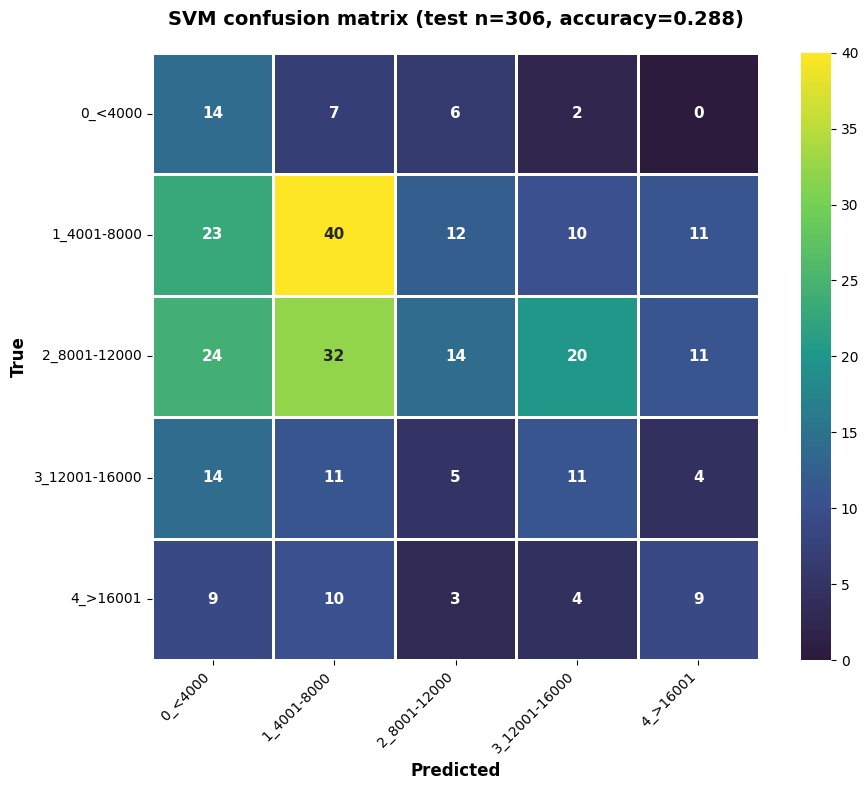

  ✓ Saved confusion matrix CSV: /data/baliu/python_code/data/confusion_matrix_svm.csv

XGBOOST

Classification Report:
               precision    recall  f1-score   support

      0_<4000     0.1875    0.4138    0.2581        29
  1_4001-8000     0.3571    0.2083    0.2632        96
 2_8001-12000     0.3810    0.2376    0.2927       101
3_12001-16000     0.1087    0.1111    0.1099        45
     4_>16001     0.1558    0.3429    0.2143        35

     accuracy                         0.2386       306
    macro avg     0.2380    0.2627    0.2276       306
 weighted avg     0.2894    0.2386    0.2443       306


Confusion Matrix (counts):
               0_<4000  1_4001-8000  2_8001-12000  3_12001-16000  4_>16001
0_<4000             12            6             7              2         2
1_4001-8000         23           20            16             14        23
2_8001-12000        16           17            24             18        26
3_12001-16000        8            6            12      

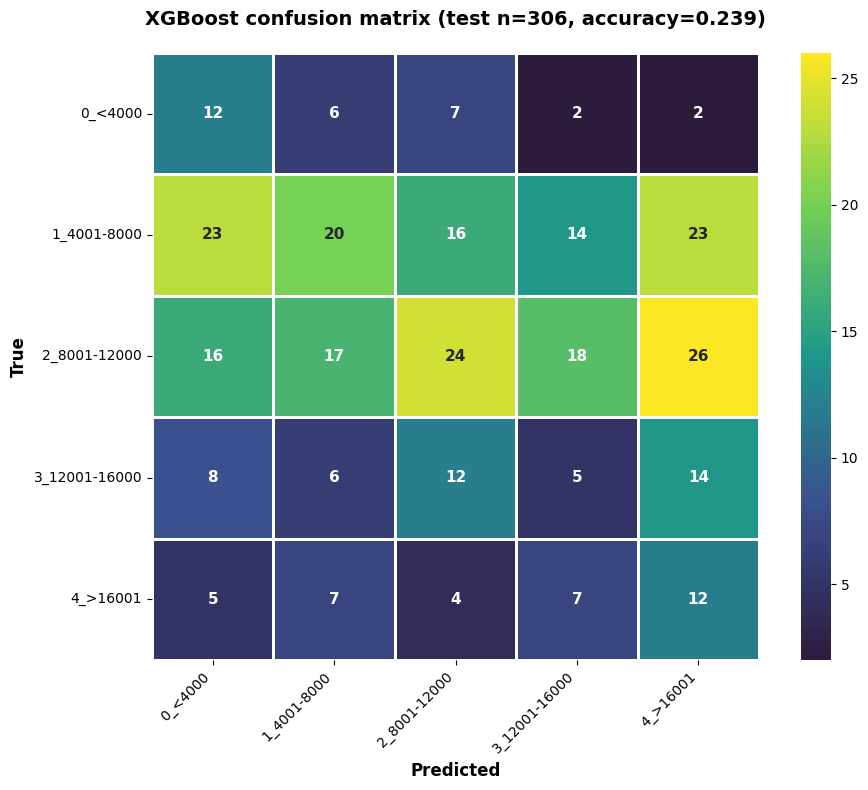

  ✓ Saved confusion matrix CSV: /data/baliu/python_code/data/confusion_matrix_xgboost.csv

MODEL COMPARISON SUMMARY

  Model  Accuracy  F1 Macro  F1 Weighted
    SVM  0.287582  0.270161     0.281657
XGBoost  0.238562  0.227616     0.244291

🏆 Best Model: SVM (F1 Macro: 0.2702)

SAVING MODELS AND RESULTS
✓ XGBoost feature importance saved
✓ SVM model saved
✓ XGBoost model saved
✓ Label encoder saved

✅ PIPELINE COMPLETED

Generated files:
  📊 confusion_matrix_svm.png & .csv
  📊 confusion_matrix_xgboost.png & .csv
  📄 feature_importance_xgb.csv
  💾 svm_model.pkl
  💾 xgb_model.pkl
  💾 label_encoder.pkl


In [11]:
"""
Household income prediction from mobility data
Using SVM (RBF kernel) and XGBoost classifiers with 10-fold CV
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================
USE_3_CLASS = False   # True → collapse into Low / Mid / High


# ============================================================================
# 1. Data loading and preprocessing
# ============================================================================

def load_data(trace_file='/data/baliu/python_code/data/sp_sampled2_v3_with_geocontext.csv',
              survey_file='/data/baliu/python_code/data/introSurvey_complete.csv'):
    trace_df  = pd.read_csv(trace_file)
    survey_df = pd.read_csv(survey_file)
    print(f"Trace data shape:  {trace_df.shape}")
    print(f"Survey data shape: {survey_df.shape}")
    return trace_df, survey_df


def categorize_income(income_value):
    """Map survey text labels → ordered income bins."""
    if pd.isna(income_value):
        return None
    s = str(income_value).strip().lower()
    if s == "prefer not to say":
        return None
    if "4 000 chf or less" in s or "4000 chf or less" in s:
        return "0_<4000"
    if "4 001 - 8 000 chf" in s:
        return "1_4001-8000"
    if "8 001 - 12 000 chf" in s:
        return "2_8001-12000"
    if "12 001 - 16 000 chf" in s:
        return "3_12001-16000"
    if "more than 16 000 chf" in s:
        return "4_>16001"
    return None


def collapse_to_3_class(cat):
    """Collapse 5 bins → 3 when minority classes are too small."""
    if cat in ("0_<4000", "1_4001-8000"):
        return "0_Low"
    if cat == "2_8001-12000":
        return "1_Mid"
    if cat in ("3_12001-16000", "4_>16001"):
        return "2_High"
    return None


def preprocess_survey_data(survey_df):
    """Preprocess survey data and create income categories."""
    print("\nPreprocessing survey data...")
    survey_df = survey_df.copy()
    survey_df['income_category'] = survey_df['income'].apply(categorize_income)
    survey_df = survey_df.dropna(subset=['income_category'])

    if USE_3_CLASS:
        survey_df['income_category'] = survey_df['income_category'].apply(collapse_to_3_class)
        survey_df = survey_df.dropna(subset=['income_category'])
        print("  → 3-class mode enabled (Low / Mid / High)")

    survey_df = survey_df[['participant_ID', 'income', 'income_category']]
    print("Income category distribution:")
    print(survey_df['income_category'].value_counts().sort_index())
    return survey_df


# ============================================================================
# 2. Feature engineering (same as before)
# ============================================================================

def parse_geometry_to_coords(geometry_series):
    coords = pd.DataFrame(index=geometry_series.index, columns=['lat', 'lon'], dtype=float)
    for idx, val in geometry_series.items():
        if pd.isna(val):
            continue
        s = str(val).strip()
        if s.upper().startswith("POINT"):
            inner = s.split("(")[-1].rstrip(")")
            parts = inner.strip().split()
            if len(parts) == 2:
                coords.at[idx, 'lon'] = float(parts[0])
                coords.at[idx, 'lat'] = float(parts[1])
        else:
            cleaned = s.strip("()")
            parts   = cleaned.split(",")
            if len(parts) == 2:
                coords.at[idx, 'lat'] = float(parts[0].strip())
                coords.at[idx, 'lon'] = float(parts[1].strip())
    return coords


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


def calculate_radius_of_gyration(coords_df):
    valid = coords_df.dropna(subset=['lat', 'lon'])
    if len(valid) < 2:
        return 0.0
    centre_lat, centre_lon = valid['lat'].mean(), valid['lon'].mean()
    d = haversine_km(valid['lat'].values, valid['lon'].values, centre_lat, centre_lon)
    return np.sqrt((d**2).mean())


def calculate_entropy(value_counts):
    p = value_counts / value_counts.sum()
    return -np.sum(p * np.log2(p + 1e-10))


def extract_temporal_features(group):
    features = {}
    features['total_trips'] = len(group)

    if 'started_at' in group.columns:
        group = group.copy()
        group['hour']        = group['started_at'].dt.hour
        group['day_of_week'] = group['started_at'].dt.dayofweek

        features['morning_peak_trips'] = ((group['hour'] >= 6)  & (group['hour'] <= 9)  & (group['day_of_week'] < 5)).sum()
        features['evening_peak_trips'] = ((group['hour'] >= 16) & (group['hour'] <= 19) & (group['day_of_week'] < 5)).sum()
        features['peak_trip_ratio']    = (features['morning_peak_trips'] + features['evening_peak_trips']) / max(features['total_trips'], 1)

        features['weekday_trips']      = (group['day_of_week'] < 5).sum()
        features['weekend_trips']      = (group['day_of_week'] >= 5).sum()
        features['weekend_trip_ratio'] = features['weekend_trips'] / max(features['total_trips'], 1)

        features['unique_hours'] = group['hour'].nunique()
        features['unique_days']  = group['started_at'].dt.date.nunique()

    return features


def extract_spatial_features(group):
    features = {}

    if 'distance' in group.columns:
        features['total_distance'] = group['distance'].sum()
        features['avg_distance']   = group['distance'].mean()
        features['max_distance']   = group['distance'].max()
        features['min_distance']   = group['distance'].min()
        features['std_distance']   = group['distance'].std() if len(group) > 1 else 0
        features['distance_range'] = features['max_distance'] - features['min_distance']

    if 'geometry' in group.columns:
        coords       = parse_geometry_to_coords(group['geometry'])
        valid_coords = coords.dropna(subset=['lat', 'lon'])

        if len(valid_coords) > 0:
            rounded      = valid_coords.copy()
            rounded['lat_r'] = rounded['lat'].round(3)
            rounded['lon_r'] = rounded['lon'].round(3)
            location_keys    = rounded[['lat_r', 'lon_r']].apply(tuple, axis=1)

            features['unique_locations']   = location_keys.nunique()
            features['location_entropy']   = calculate_entropy(location_keys.value_counts())
            features['radius_of_gyration'] = calculate_radius_of_gyration(valid_coords)
        else:
            features['unique_locations']   = 0
            features['location_entropy']   = 0.0
            features['radius_of_gyration'] = 0.0

    elif 'lat' in group.columns and 'lon' in group.columns:
        valid_coords = group[['lat', 'lon']].dropna()
        if len(valid_coords) > 0:
            rounded      = valid_coords.copy()
            rounded['lat_r'] = rounded['lat'].round(3)
            rounded['lon_r'] = rounded['lon'].round(3)
            location_keys    = rounded[['lat_r', 'lon_r']].apply(tuple, axis=1)

            features['unique_locations']   = location_keys.nunique()
            features['location_entropy']   = calculate_entropy(location_keys.value_counts())
            features['radius_of_gyration'] = calculate_radius_of_gyration(valid_coords)
        else:
            features['unique_locations']   = 0
            features['location_entropy']   = 0.0
            features['radius_of_gyration'] = 0.0

    return features


def extract_mode_features(group):
    features = {}
    if 'mode' in group.columns:
        mode_counts = group['mode'].value_counts()
        total       = len(group)
        for mode in group['mode'].unique():
            features[f'mode_{mode}_count'] = mode_counts.get(mode, 0)
            features[f'mode_{mode}_ratio'] = mode_counts.get(mode, 0) / total
        features['mode_diversity']      = group['mode'].nunique()
        features['mode_entropy']        = calculate_entropy(mode_counts)
        features['dominant_mode_ratio'] = mode_counts.max() / total
    return features


def build_features_per_user(trace_df):
    print("\nBuilding features from mobility traces...")
    all_features = []

    for user_id, grp in trace_df.groupby('user_id'):
        feat = {'user_id': user_id}
        feat.update(extract_temporal_features(grp))
        feat.update(extract_spatial_features(grp))
        feat.update(extract_mode_features(grp))

        if 'total_trips' in feat and 'unique_days' in feat:
            feat['trips_per_day']    = feat['total_trips']    / max(feat['unique_days'], 1)
        if 'total_distance' in feat and 'unique_days' in feat:
            feat['distance_per_day'] = feat['total_distance'] / max(feat['unique_days'], 1)

        all_features.append(feat)

    features_df = pd.DataFrame(all_features).fillna(0)
    print(f"Feature matrix shape: {features_df.shape}")
    print(f"Number of features:   {len(features_df.columns) - 1}")
    return features_df


# ============================================================================
# 3. Train / test prep
# ============================================================================

def prepare_train_test_data(features_df, survey_df, test_size=0.2, random_state=42):
    print("\n" + "="*70)
    print("PREPARING DATA")
    print("="*70)

    merged = features_df.merge(survey_df, left_on='user_id', right_on='participant_ID', how='inner')
    print(f"Merged data: {len(merged)} users with both trace and income data")

    feature_cols = [c for c in merged.columns
                    if c not in ['user_id', 'participant_ID', 'income', 'income_category']]

    X = merged[feature_cols]
    y = merged['income_category']

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    print(f"Features: {len(feature_cols)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=test_size, random_state=random_state, stratify=y_enc
    )
    print(f"Training set: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"Test set: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
    
    return X_train, X_test, y_train, y_test, le, feature_cols

# ============================================================================
# 4. SVM with 10-fold CV
# ============================================================================

def train_svm_model(X_train, y_train, X_test, y_test):
    print("\n" + "="*70)
    print("SVM MODEL - 10-FOLD CROSS-VALIDATION")
    print("="*70)

    # Scale features 
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    param_grid = {
        'C':     [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.001],
        'kernel': ['rbf']
    }

    total_combinations = len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])
    
    print(f"Testing {total_combinations} hyperparameter combinations with 10-fold CV...")
    print(f"Total fits: {total_combinations * 10}")

    svm = SVC(class_weight='balanced', probability=True, random_state=42)

    grid = GridSearchCV(
        svm, param_grid,
        cv=10,                    # 10-fold CV
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0,                # No verbose output
        return_train_score=True
    )
    
    print("Training in progress...")
    grid.fit(X_train_s, y_train)

    print(f"\n{'='*70}")
    print("VALIDATION RESULTS")
    print(f"{'='*70}")
    print(f"Best hyperparameters: {grid.best_params_}")
    print(f"Best CV f1_macro: {grid.best_score_:.4f} (±{grid.cv_results_['std_test_score'][grid.best_index_]:.4f})")

    # Show top 3
    cv_results = pd.DataFrame(grid.cv_results_)
    top_3 = cv_results.nsmallest(3, 'rank_test_score')[
        ['params', 'mean_test_score', 'std_test_score']
    ]
    print("\nTop 3 configurations:")
    for idx, row in top_3.iterrows():
        print(f"  {row['params']}")
        print(f"    → CV: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")

    best_svm = grid.best_estimator_

    # Final evaluation
    y_pred_train = best_svm.predict(X_train_s)
    y_pred_test  = best_svm.predict(X_test_s)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy  = accuracy_score(y_test, y_pred_test)
    test_f1        = f1_score(y_test, y_pred_test, average='macro')

    print(f"\n{'='*70}")
    print("FINAL PERFORMANCE")
    print(f"{'='*70}")
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Test accuracy:     {test_accuracy:.4f}")
    print(f"Test f1_macro:     {test_f1:.4f}")
    print(f"CV f1_macro:       {grid.best_score_:.4f}")

    if train_accuracy - test_accuracy > 0.1:
        print(f"\n Overfitting detected (gap: {train_accuracy - test_accuracy:.4f})")
    else:
        print(f"\n✓ Model generalizes well")

    return best_svm, scaler


# ============================================================================
# 5. XGBoost with proper validation  (test set locked until final evaluation)
# ============================================================================

def compute_sample_weights(y_train):
    """Mirror sklearn's class_weight='balanced'"""
    classes, counts = np.unique(y_train, return_counts=True)
    n_samples       = len(y_train)
    n_classes       = len(classes)
    weight_map      = dict(zip(classes, n_samples / (n_classes * counts)))
    return np.array([weight_map[y] for y in y_train])


def train_xgboost_model(X_train, y_train, X_test, y_test, feature_cols):
    print("\n" + "="*70)
    print("XGBOOST MODEL - VALIDATION WITH EARLY STOPPING")
    print("="*70)

    n_classes = len(np.unique(y_train))
    sample_weights = compute_sample_weights(y_train)

    param_candidates = [
        # (max_depth, learning_rate, subsample, colsample_bytree)
        (3,  0.05,  0.8, 0.8),
        (3,  0.1,   0.8, 0.8),
        (4,  0.05,  0.8, 0.8),
        (4,  0.1,   0.8, 0.8),
        (5,  0.05,  0.8, 0.8),
        (5,  0.1,   0.8, 0.8),
        (6,  0.05,  0.8, 0.8),
        (6,  0.1,   0.8, 0.8),
        (4,  0.05,  0.7, 0.7),
        (4,  0.1,   0.7, 0.7),
        (5,  0.05,  0.7, 0.7),
        (5,  0.1,   0.7, 0.7),
    ]

    # Split train into train + validation for early stopping
    #  Use validation set, not test set for selection
    X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
        X_train, y_train, sample_weights,
        test_size=0.15, random_state=42, stratify=y_train
    )

    print(f"Testing {len(param_candidates)} hyperparameter combinations...")
    print(f"  Training samples: {len(X_tr)}")
    print(f"  Validation samples: {len(X_val)}")
    print(f"  Test samples: {len(X_test)} (locked until final evaluation)")

    best_f1      = -1.0
    best_model   = None
    best_params  = None
    results_log  = []

    print("\nTraining in progress...")

    for i, (md, lr, ss, cs) in enumerate(param_candidates):
        model = xgb.XGBClassifier(
            objective          = 'multi:softprob',
            num_class          = n_classes,
            eval_metric        = 'mlogloss',
            max_depth          = md,
            learning_rate      = lr,
            n_estimators       = 1000,
            subsample          = ss,
            colsample_bytree   = cs,
            reg_alpha          = 0.1,
            reg_lambda         = 1.0,
            random_state       = 42,
            use_label_encoder  = False,
            tree_method        = 'hist',
            early_stopping_rounds = 20
        )

        model.fit(
            X_tr, y_tr,
            sample_weight  = w_tr,
            eval_set       = [(X_val, y_val)],
            sample_weight_eval_set = [w_val],
            verbose        = False
        )

        # Evaluate on VALIDATION set, not test set
        y_pred_val = model.predict(X_val)
        f1_val = f1_score(y_val, y_pred_val, average='macro')

        results_log.append({
            'max_depth': md, 'lr': lr, 'subsample': ss,
            'colsample': cs, 'best_iteration': model.best_iteration,
            'f1_macro_val': f1_val
        })

        if f1_val > best_f1:
            best_f1     = f1_val
            best_model  = model
            best_params = {'max_depth': md, 'learning_rate': lr,
                           'subsample': ss, 'colsample_bytree': cs}

    print(f"\n{'='*70}")
    print("VALIDATION RESULTS")
    print(f"{'='*70}")
    print(f"Best hyperparameters:")
    for param, value in best_params.items():
        print(f"  - {param}: {value}")
    print(f"\nBest validation f1_macro: {best_f1:.4f}")
    print(f"Best iteration: {best_model.best_iteration}")

    # Show top 3
    results_df = pd.DataFrame(results_log).sort_values('f1_macro_val', ascending=False)
    print("\nTop 3 configurations:")
    for i, row in results_df.head(3).iterrows():
        print(f"  depth={row['max_depth']} lr={row['lr']} sub={row['subsample']} col={row['colsample']}")
        print(f"    → Val f1: {row['f1_macro_val']:.4f}, Iterations: {row['best_iteration']}")

    # Retrain best config on FULL training set
    print(f"\nRetraining best model on full training set...")
    final_model = xgb.XGBClassifier(
        objective          = 'multi:softprob',
        num_class          = n_classes,
        eval_metric        = 'mlogloss',
        max_depth          = best_params['max_depth'],
        learning_rate      = best_params['learning_rate'],
        n_estimators       = best_model.best_iteration + 1,
        subsample          = best_params['subsample'],
        colsample_bytree   = best_params['colsample_bytree'],
        reg_alpha          = 0.1,
        reg_lambda         = 1.0,
        random_state       = 42,
        use_label_encoder  = False,
        tree_method        = 'hist'
    )
    full_weights = compute_sample_weights(y_train)
    final_model.fit(X_train, y_train, sample_weight=full_weights, verbose=False)

    # Final evaluation
    y_pred_train = final_model.predict(X_train)
    y_pred_test  = final_model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy  = accuracy_score(y_test, y_pred_test)
    test_f1        = f1_score(y_test, y_pred_test, average='macro')

    print(f"\n{'='*70}")
    print("FINAL PERFORMANCE")
    print(f"{'='*70}")
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Test accuracy:     {test_accuracy:.4f}")
    print(f"Test f1_macro:     {test_f1:.4f}")
    print(f"Val f1_macro:      {best_f1:.4f}")

    if train_accuracy > test_accuracy + 0.1:
        print(f"\nOverfitting detected (gap: {train_accuracy - test_accuracy:.4f})")
    else:
        print(f"\n✓ Model generalizes well")

    # Feature importance
    importance = pd.DataFrame({
        'feature':    feature_cols,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(importance.head(10).to_string(index=False))

    return final_model, importance


# ============================================================================
# 6. Evaluation
# ============================================================================

def evaluate_models(models_dict, X_test, y_test, label_encoder):
    """Detailed evaluation for all models"""
    print("\n" + "="*70)
    print("DETAILED MODEL COMPARISON")
    print("="*70)

    for name, info in models_dict.items():
        print(f"\n{'='*70}\n{name.upper()}\n{'='*70}")

        model = info['model']
        X_proc = info['scaler'].transform(X_test) if 'scaler' in info else X_test
        y_pred = model.predict(X_proc)

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred,
                                    target_names=label_encoder.classes_, digits=4))

        print("\nConfusion Matrix:")
        cm = pd.DataFrame(confusion_matrix(y_test, y_pred),
                          index=label_encoder.classes_,
                          columns=label_encoder.classes_)
        print(cm)
        print(f"\nOverall Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")


def print_comparison(models_dict, X_test, y_test, label_encoder):
    """Side-by-side model comparison"""
    print("\n" + "="*70)
    print("MODEL COMPARISON SUMMARY")
    print("="*70)

    rows = []
    for name, info in models_dict.items():
        model  = info['model']
        X_proc = info['scaler'].transform(X_test) if 'scaler' in info else X_test
        y_pred = model.predict(X_proc)

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        rows.append({
            'Model': name,
            'Accuracy': acc,
            'F1 Macro': f1_macro,
            'F1 Weighted': f1_weighted
        })

    comp_df = pd.DataFrame(rows)
    print(comp_df.to_string(index=False))


# ============================================================================
# 7. Main
# ============================================================================

def main():
    print("="*70)
    print("HOUSEHOLD INCOME PREDICTION - SVM + XGBOOST")
    print("="*70)

    # 1. Load data
    trace_df, survey_df = load_data()

    # 2. Preprocess survey
    survey_df = preprocess_survey_data(survey_df)

    # 3. Parse datetime
    trace_df['started_at']  = pd.to_datetime(trace_df['started_at'],  errors='coerce')
    trace_df['finished_at'] = pd.to_datetime(trace_df['finished_at'], errors='coerce')
    trace_df = trace_df.dropna(subset=['started_at', 'finished_at'])

    # 4. Build features
    features_df = build_features_per_user(trace_df)

    # 5. Split train/test
    X_train, X_test, y_train, y_test, label_encoder, feature_cols = \
        prepare_train_test_data(features_df, survey_df)

    # 6. Train SVM with 10-fold CV
    svm_model, svm_scaler = train_svm_model(X_train, y_train, X_test, y_test)

    # 7. Train XGBoost with proper validation
    xgb_model, xgb_importance = train_xgboost_model(
        X_train, y_train, X_test, y_test, feature_cols)

    # 8. Evaluate
    models_dict = {
        'SVM':     {'model': svm_model,  'scaler': svm_scaler},
        'XGBoost': {'model': xgb_model}
    }
    
    evaluate_models(models_dict, X_test, y_test, label_encoder)
    print_comparison(models_dict, X_test, y_test, label_encoder)

    # 9. Save
    xgb_importance.to_csv('/data/baliu/python_code/data/feature_importance_xgb.csv', index=False)

    import pickle
    with open('/data/baliu/python_code/data/svm_model.pkl', 'wb') as f:
        pickle.dump({'model': svm_model, 'scaler': svm_scaler}, f)
    with open('/data/baliu/python_code/data/xgb_model.pkl', 'wb') as f:
        pickle.dump(xgb_model, f)
    with open('/data/baliu/python_code/data/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)

    print("\n" + "="*70)
    print("✓ PIPELINE COMPLETED")
    print("="*70)


if __name__ == "__main__":
    main()  


import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

# ============================================================================
# CONFUSION MATRIX VISUALIZATION (Same as before)
# ============================================================================

def plot_confusion_matrix(y_true, y_pred, labels, model_name, save_path=None):
    """
    Plot confusion matrix heatmap similar to the XGBoost visualization.
    
    Parameters:
    -----------
    y_true : array-like
        True labels (encoded)
    y_pred : array-like
        Predicted labels (encoded)
    labels : list
        List of label names (from label_encoder.classes_)
    model_name : str
        Name of the model (e.g., 'SVM', 'XGBoost')
    save_path : str, optional
        Path to save the figure
    """
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Custom colormap (purple to yellow like your image)
    colors = ['#2d1b3d', '#3a4f8f', '#1f968b', '#73d055', '#fde724']
    cmap = LinearSegmentedColormap.from_list('custom', colors, N=100)
    
    # Create figure
    plt.figure(figsize=(10, 8))
    
    # Create heatmap
    sns.heatmap(
        cm, 
        annot=True,
        fmt='d',
        cmap=cmap,
        cbar=True,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=1,
        linecolor='white',
        square=True,
        annot_kws={'size': 11, 'weight': 'bold'}
    )
    
    # Add title with test sample count
    n_test = len(y_true)
    acc = accuracy_score(y_true, y_pred)
    plt.title(f'{model_name} confusion matrix (test n={n_test}, accuracy={acc:.3f})', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Labels
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('True', fontsize=12, fontweight='bold')
    
    # Rotate labels if needed
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ Saved confusion matrix: {save_path}")
    
    plt.show()
    plt.close()


# ============================================================================
# EVALUATION WITH CONFUSION MATRICES
# ============================================================================

def evaluate_models_with_plots(models_dict, X_test, y_test, label_encoder, 
                                save_dir='/data/baliu/python_code/data/'):
    """
    Evaluate models with detailed metrics and confusion matrix plots.
    """
    print("\n" + "="*70)
    print("DETAILED MODEL COMPARISON WITH CONFUSION MATRICES")
    print("="*70)

    for name, info in models_dict.items():
        print(f"\n{'='*70}")
        print(f"{name.upper()}")
        print(f"{'='*70}")
        
        # Get model and process data
        model = info['model']
        X_proc = info['scaler'].transform(X_test) if 'scaler' in info else X_test
        y_pred = model.predict(X_proc)

        # Classification Report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred,
                                    target_names=label_encoder.classes_, 
                                    digits=4))
        
        # Text-based Confusion Matrix
        print("\nConfusion Matrix (counts):")
        cm = pd.DataFrame(confusion_matrix(y_test, y_pred),
                          index=label_encoder.classes_,
                          columns=label_encoder.classes_)
        print(cm)
        
        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        
        print(f"\nOverall Test Accuracy: {acc:.4f}")
        print(f"F1 Macro:              {f1_macro:.4f}")
        print(f"F1 Weighted:           {f1_weighted:.4f}")
        
        # Generate Confusion Matrix Plot
        print(f"\nGenerating confusion matrix plot for {name}...")
        save_path = f"{save_dir}confusion_matrix_{name.replace(' ', '_').lower()}.png"
        plot_confusion_matrix(
            y_test, 
            y_pred, 
            label_encoder.classes_, 
            name,
            save_path=save_path
        )
        
        # Save confusion matrix as CSV
        cm_csv_path = f"{save_dir}confusion_matrix_{name.replace(' ', '_').lower()}.csv"
        cm.to_csv(cm_csv_path)
        print(f"  ✓ Saved confusion matrix CSV: {cm_csv_path}")


def print_comparison(models_dict, X_test, y_test, label_encoder):
    """
    Print side-by-side model comparison.
    """
    print("\n" + "="*70)
    print("MODEL COMPARISON SUMMARY")
    print("="*70)

    rows = []
    for name, info in models_dict.items():
        model = info['model']
        X_proc = info['scaler'].transform(X_test) if 'scaler' in info else X_test
        y_pred = model.predict(X_proc)

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        rows.append({
            'Model': name,
            'Accuracy': acc,
            'F1 Macro': f1_macro,
            'F1 Weighted': f1_weighted
        })

    comp_df = pd.DataFrame(rows)
    print("\n" + comp_df.to_string(index=False))
    
    # Find best model
    best_model = comp_df.loc[comp_df['F1 Macro'].idxmax(), 'Model']
    best_f1 = comp_df['F1 Macro'].max()
    print(f"\n🏆 Best Model: {best_model} (F1 Macro: {best_f1:.4f})")


# ============================================================================
# MAIN FUNCTION
# ============================================================================

def main():
    print("="*70)
    print("HOUSEHOLD INCOME PREDICTION - SVM + XGBOOST")
    print("Full spatiotemporal features with 10-fold CV")
    print("="*70)

    # 1. Load data
    trace_df, survey_df = load_data()

    # 2. Preprocess survey
    survey_df = preprocess_survey_data(survey_df)

    # 3. Parse datetime
    trace_df['started_at'] = pd.to_datetime(trace_df['started_at'], errors='coerce')
    trace_df['finished_at'] = pd.to_datetime(trace_df['finished_at'], errors='coerce')
    trace_df = trace_df.dropna(subset=['started_at', 'finished_at'])

    # 4. Build features
    features_df = build_features_per_user(trace_df)

    # 5. Split train/test
    X_train, X_test, y_train, y_test, label_encoder, feature_cols = \
        prepare_train_test_data(features_df, survey_df)

    # 6. Train SVM with 10-fold CV
    svm_model, svm_scaler = train_svm_model(X_train, y_train, X_test, y_test)

    # 7. Train XGBoost with proper validation
    xgb_model, xgb_importance = train_xgboost_model(
        X_train, y_train, X_test, y_test, feature_cols)

    # 8. Evaluate with confusion matrix plots
    models_dict = {
        'SVM':     {'model': svm_model, 'scaler': svm_scaler},
        'XGBoost': {'model': xgb_model}
    }
    
    # ✅ Use the new evaluation function with plots
    evaluate_models_with_plots(models_dict, X_test, y_test, label_encoder)
    
    # Print comparison table
    print_comparison(models_dict, X_test, y_test, label_encoder)

    # 9. Save models and results
    print("\n" + "="*70)
    print("SAVING MODELS AND RESULTS")
    print("="*70)
    
    # Save feature importance
    xgb_importance.to_csv('/data/baliu/python_code/data/feature_importance_xgb.csv', index=False)
    print("✓ XGBoost feature importance saved")

    # Save models
    import pickle
    
    with open('/data/baliu/python_code/data/svm_model.pkl', 'wb') as f:
        pickle.dump({'model': svm_model, 'scaler': svm_scaler}, f)
    print("✓ SVM model saved")
    
    with open('/data/baliu/python_code/data/xgb_model.pkl', 'wb') as f:
        pickle.dump(xgb_model, f)
    print("✓ XGBoost model saved")
    
    with open('/data/baliu/python_code/data/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    print("✓ Label encoder saved")

    # Summary
    print("\n" + "="*70)
    print("✅ PIPELINE COMPLETED")
    print("="*70)
    print("\nGenerated files:")
    print("  📊 confusion_matrix_svm.png & .csv")
    print("  📊 confusion_matrix_xgboost.png & .csv")
    print("  📄 feature_importance_xgb.csv")
    print("  💾 svm_model.pkl")
    print("  💾 xgb_model.pkl")
    print("  💾 label_encoder.pkl")
    print("="*70)


if __name__ == "__main__":
    main()

Based on the paper of (Wu et al., 2019)

use SVM and XGBoost methods

HOUSEHOLD INCOME PREDICTION - SVM + XGBOOST
Full spatiotemporal features with 10-fold CV
Trace data shape:  (60738, 23)
Survey data shape: (90909, 124)

Preprocessing survey data...
Income category distribution:
income_category
0_<4000          2618
1_4001-8000      6454
2_8001-12000     5285
3_12001-16000    2575
4_>16001         1700
Name: count, dtype: int64

Building features from mobility traces …
  Feature matrix shape (before semantic/unicity): (2102, 231)
  Computing unicity …

Preparing training and test data …
Merged shape: (1527, 240)   |   matched users: 1527

Feature columns (236):
['total_trips_all', 'morning_peak_trips_all', 'evening_peak_trips_all', 'peak_trip_ratio_all', 'weekday_trips_all', 'weekend_trips_all', 'weekend_trip_ratio_all', 'unique_hours_all', 'unique_days_all', 'time_fragmentation_all', 'rhythm_q3_bin0_all', 'rhythm_q3_bin1_all', 'rhythm_q3_bin2_all', 'rhythm_q3_entropy_all', 'rhythm_q8_bin0_all'] …
Train: 1221   Test: 306

Training SVM model  (RBF kerne

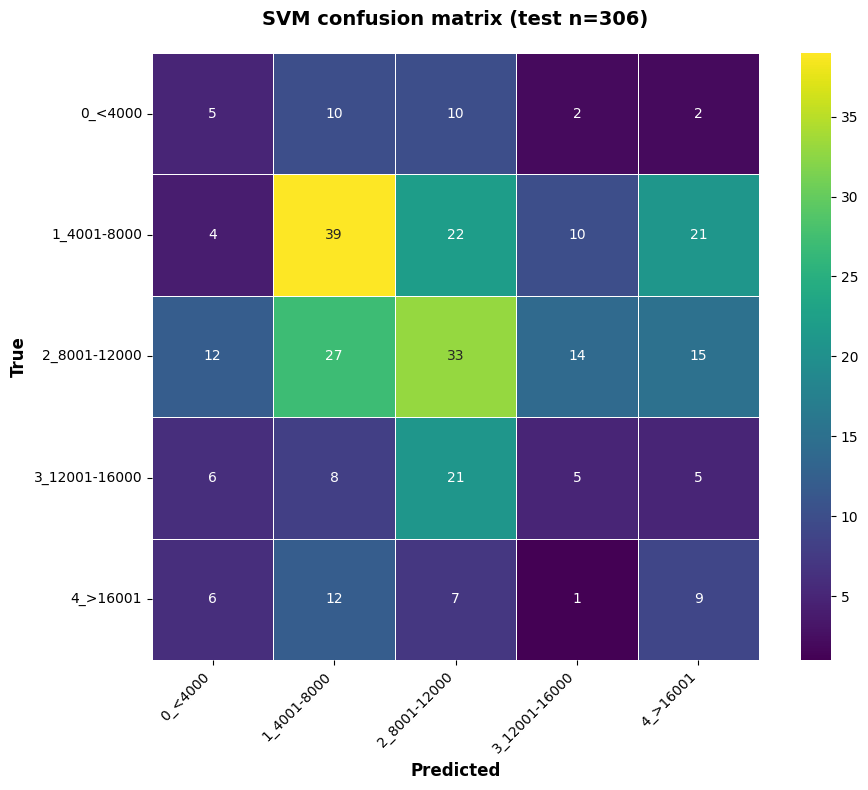


XGBOOST

Classification Report:
               precision    recall  f1-score   support

      0_<4000     0.2500    0.3793    0.3014        29
  1_4001-8000     0.4154    0.2812    0.3354        96
 2_8001-12000     0.4032    0.2475    0.3067       101
3_12001-16000     0.1613    0.2222    0.1869        45
     4_>16001     0.1781    0.3714    0.2407        35

     accuracy                         0.2810       306
    macro avg     0.2816    0.3003    0.2742       306
 weighted avg     0.3312    0.2810    0.2901       306


Confusion Matrix (text):
               0_<4000  1_4001-8000  2_8001-12000  3_12001-16000  4_>16001
0_<4000             11            2             9              1         6
1_4001-8000         11           27            17             16        25
2_8001-12000        11           23            25             25        17
3_12001-16000        9            6             8             10        12
4_>16001             2            7             3             10    

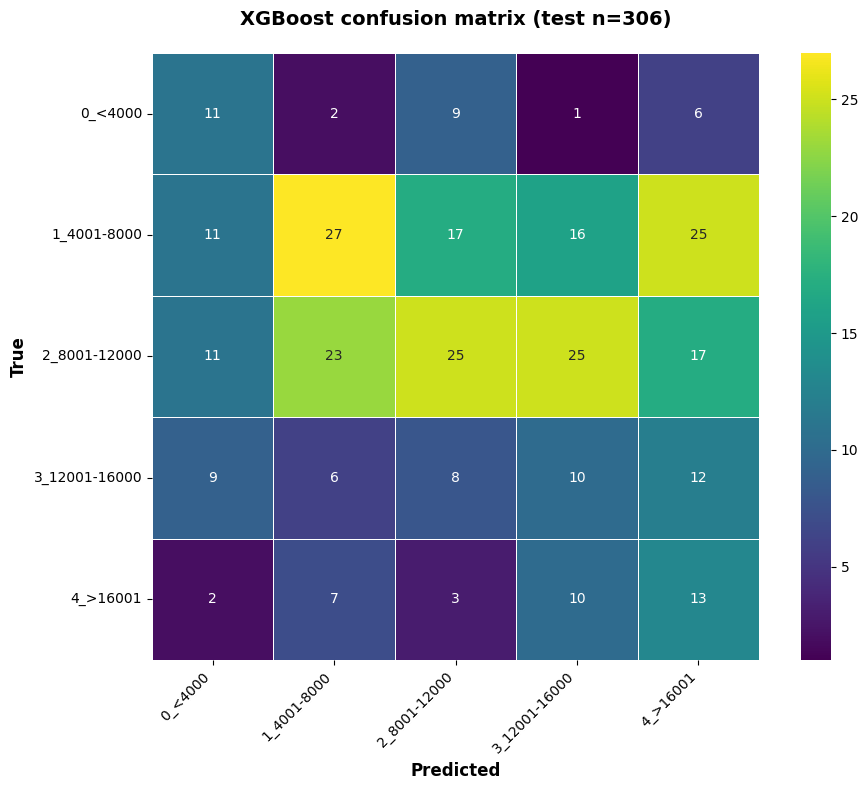


MODEL COMPARISON SUMMARY
  Model  Accuracy  F1 Macro  F1 Weighted
    SVM  0.297386  0.248903     0.297790
XGBoost  0.281046  0.274236     0.290056

✓ PIPELINE COMPLETED
  - Confusion matrices saved as PNG files
  - Models saved as PKL files


In [5]:
"""
Household income prediction from mobility data
Using SVM (RBF kernel) and XGBoost classifiers

Feature engineering rebuilt to match the paper's full framework:
    (1) Spatial   : 1-order point, 2-order line, k-order motif
    (2) Temporal  : fragmentation, travel rhythm (q=3,8,24), rhythm entropy
    (3) Space-time integrated k-rog ratio, top-2 stay coords, unicity
    (4) Semantic  : land-use buffer ratios ordered by stay duration

All spatiotemporal features are computed on 3 slices:
    all / weekday / weekend   (suffix: _all, _wd, _we)

Land-use data:  /data/baliu/python_code/data/arealstatistik_2056.gpkg
    • the CRS  : EPSG:2056 (CH1903+ / LV95)
    • Buffer radius : 200 m  (configurable )

Classifier pipeline is unchanged from the previous version:
    - class_weight='balanced' (SVM) / sample_weight (XGBoost)
    - f1_macro scoring
    - StandardScaler for SVM
    - Manual grid + early stopping for XGBoost
"""

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
import xgboost as xgb
# pip install xgboost
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# configration
# ============================================================================
USE_3_CLASS        = False   # True  →  collapse into Low / Mid / High
#LANDUSE_BUFFER_M   = 200     # buffer radius in metres (projected CRS)
LANDUSE_FILE       = '/data/baliu/python_code/data/arealstatistik_2056.gpkg'
# Motif frequency threshold: motifs appearing in < εm % of users are dropped
MOTIF_EPSILON_PCT  = 1.0     # percent

# ============================================================================
# 1. Data loading and preprocessing   (unchanged)
# ============================================================================

def load_data(trace_file='/data/baliu/python_code/data/sp_sampled2_v3_with_geocontext.csv',
              survey_file='/data/baliu/python_code/data/introSurvey_complete.csv'):
    trace_df  = pd.read_csv(trace_file)
    survey_df = pd.read_csv(survey_file)
    print(f"Trace data shape:  {trace_df.shape}")
    print(f"Survey data shape: {survey_df.shape}")
    return trace_df, survey_df


def categorize_income(income_value):
    """Map survey text labels → ordered income bins."""
    if pd.isna(income_value):
        return None
    s = str(income_value).strip().lower()
    if s == "prefer not to say":
        return None
    if "4 000 chf or less" in s or "4000 chf or less" in s:
        return "0_<4000"
    if "4 001 - 8 000 chf" in s:
        return "1_4001-8000"
    if "8 001 - 12 000 chf" in s:
        return "2_8001-12000"
    if "12 001 - 16 000 chf" in s:
        return "3_12001-16000"
    if "more than 16 000 chf" in s:
        return "4_>16001"
    return None


# def collapse_to_3_class(cat):
#     if cat in ("0_<4000", "1_4001-8000"):
#         return "0_Low"
#     if cat == "2_8001-12000":
#         return "1_Mid"
#     if cat in ("3_12001-16000", "4_>16001"):
#         return "2_High"
#     return None


def preprocess_survey_data(survey_df):
    print("\nPreprocessing survey data...")
    survey_df = survey_df.copy()
    survey_df['income_category'] = survey_df['income'].apply(categorize_income)
    survey_df = survey_df.dropna(subset=['income_category'])

    # if USE_3_CLASS:
    #     survey_df['income_category'] = survey_df['income_category'].apply(collapse_to_3_class)
    #     survey_df = survey_df.dropna(subset=['income_category'])
    #     print("  → 3-class mode enabled (Low / Mid / High)")

    survey_df = survey_df[['participant_ID', 'income', 'income_category']]
    print("Income category distribution:")
    print(survey_df['income_category'].value_counts().sort_index())
    return survey_df


# ============================================================================
# 2. Geometry & haversine utilities   (for spatial features)
# ============================================================================

def parse_geometry_to_coords(geometry_series):
    """
    Extract (lat, lon) from a geometry column.
    Handles  "POINT (lon lat)"  and  "(lat, lon)".
    """
    coords = pd.DataFrame(index=geometry_series.index, columns=['lat', 'lon'], dtype=float)
    for idx, val in geometry_series.items():
        if pd.isna(val):
            continue
        s = str(val).strip()
        if s.upper().startswith("POINT"):
            inner = s.split("(")[-1].rstrip(")")
            parts = inner.strip().split()
            if len(parts) == 2:
                coords.at[idx, 'lon'] = float(parts[0])
                coords.at[idx, 'lat'] = float(parts[1])
        else:
            cleaned = s.strip("()")
            parts   = cleaned.split(",")
            if len(parts) == 2:
                coords.at[idx, 'lat'] = float(parts[0].strip())
                coords.at[idx, 'lon'] = float(parts[1].strip())
    return coords


def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorised haversine → km."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


def shannon_entropy(counts):
    """Shannon entropy from an array / Series of counts."""
    p = np.asarray(counts, dtype=float)
    p = p[p > 0]
    p = p / p.sum()
    return -np.sum(p * np.log2(p + 1e-10))


# ============================================================================
# 3. Spatial features  –  1-order, 2-order, k-order motif
# ============================================================================

def _get_coords(group):
    """Return a clean (lat, lon) DataFrame from the group, NaN-free."""
    if 'geometry' in group.columns:
        coords = parse_geometry_to_coords(group['geometry'])
    elif 'lat' in group.columns and 'lon' in group.columns:
        coords = group[['lat', 'lon']].copy()
    else:
        return pd.DataFrame(columns=['lat', 'lon'])
    return coords.dropna(subset=['lat', 'lon'])


def _unique_stay_points(coords_df, decimals=3):
    """Round to `decimals` and return a Series of (lat_r, lon_r) keys."""
    r = coords_df.copy()
    r['lat_r'] = r['lat'].round(decimals)
    r['lon_r'] = r['lon'].round(decimals)
    return r[['lat_r', 'lon_r']].apply(tuple, axis=1)


# ── 1-order  (point-level) ─────────────────────────────────────────────────

def radius_of_gyration(coords_df):
    """ROG = sqrt( mean( haversine(pt, centroid)² ) )  in km."""
    if len(coords_df) < 2:
        return 0.0
    c_lat, c_lon = coords_df['lat'].mean(), coords_df['lon'].mean()
    d = haversine_km(coords_df['lat'].values, coords_df['lon'].values, c_lat, c_lon)
    return np.sqrt((d**2).mean())


def convex_hull_diameter(coords_df):
    """
    Diameter = max pairwise haversine distance among unique stay points.
    For efficiency cap at 200 unique points (random sample).
    """
    if len(coords_df) < 2:
        return 0.0
    pts = coords_df[['lat', 'lon']].drop_duplicates()
    if len(pts) > 200:
        pts = pts.sample(200, random_state=42)
    lats = pts['lat'].values
    lons = pts['lon'].values
    # vectorised pairwise
    lat_grid = np.abs(lats[:, None] - lats[None, :])   # quick pre-filter
    max_d = 0.0
    for i in range(len(lats)):
        d = haversine_km(lats[i], lons[i], lats, lons)
        candidate = d.max()
        if candidate > max_d:
            max_d = candidate
    return max_d


def ellipse_features(coords_df):
    """
    PCA on (lat, lon) → semi-axes e1 >= e2.
    Returns area (π·e1·e2), eccentricity, direction (deg).

    PCA is done in degree-space which is an approximation but consistent
    with the paper's formulation (they use Cartesian coordinates of stay
    points directly).
    """
    if len(coords_df) < 3:
        return {'trajectory_area': 0.0, 'eccentricity': 0.0, 'direction': 0.0}

    X = coords_df[['lat', 'lon']].values.astype(float)
    X_c = X - X.mean(axis=0)                      # centre
    cov = np.cov(X_c, rowvar=False)               # 2×2 covariance
    eigvals, eigvecs = np.linalg.eigh(cov)        # ascending order
    # semi-axis lengths = sqrt of eigenvalues  (std along each PC)
    e2 = np.sqrt(max(eigvals[0], 0.0))            # minor
    e1 = np.sqrt(max(eigvals[1], 0.0))            # major

    area = np.pi * e1 * e2                        # ellipse area (degree²)
    ecc  = np.sqrt(1.0 - (e2 / e1)**2) if e1 > 0 else 0.0

    # direction: angle of major eigenvector vs (1, 0)  → degrees
    major_vec = eigvecs[:, 1]                     # eigvec for largest eigval
    angle_rad = np.arccos(
        np.clip(np.dot(major_vec, [1, 0]) / (np.linalg.norm(major_vec) + 1e-30), -1, 1)
    )
    direction = np.degrees(angle_rad)

    return {'trajectory_area': area, 'eccentricity': ecc, 'direction': direction}


# ── 2-order  (line-level) ──────────────────────────────────────────────────

def travel_od_entropy(group, coords_df):
    """
    OD-pair entropy  −Σ p(s_i → s_{i+1}) log p(s_i → s_{i+1})
    using rounded stay-point keys as node identifiers.
    Requires the group to be sorted by time (caller's responsibility).
    """
    keys = _unique_stay_points(coords_df.reindex(group.index).dropna(subset=['lat', 'lon']))
    if len(keys) < 2:
        return 0.0
    # consecutive OD pairs
    od_pairs = list(zip(keys.values[:-1], keys.values[1:]))
    counts = Counter(od_pairs)
    return shannon_entropy(list(counts.values()))


# ── k-order  (motif) ──────────────────────────────────────────────────────

def _daily_motif_hash(day_group, coords_df):
    """
    Build the adjacency matrix for one day's trajectory, then return a
    canonical hash (sorted row-tuple of the adjacency matrix).

    Nodes = unique rounded stay-point keys visited that day.
    Directed edges = consecutive OD transitions.
    """
    keys = _unique_stay_points(coords_df.reindex(day_group.index).dropna(subset=['lat', 'lon']))
    if len(keys) < 2:
        return None
    unique_nodes = sorted(set(keys.values))
    node_idx     = {n: i for i, n in enumerate(unique_nodes)}
    n            = len(unique_nodes)
    adj          = np.zeros((n, n), dtype=int)
    for a, b in zip(keys.values[:-1], keys.values[1:]):
        adj[node_idx[a], node_idx[b]] += 1

    # Canonical form: sort rows lexicographically (simple isomorphism approx)
    row_tuples = tuple(sorted(tuple(row) for row in adj.tolist()))
    return row_tuples


def extract_motif_features(group, coords_df):
    """
    Per-user: count daily-motif types and return ratio features.
    Motifs that appear in < MOTIF_EPSILON_PCT % of the dataset are kept
    but may be pruned later in a global pass (see note in main).
    """
    if 'started_at' not in group.columns:
        return {'n_motif_types': 0}

    daily_hashes = []
    for _date, day_grp in group.sort_values('started_at').groupby(group['started_at'].dt.date):
        h = _daily_motif_hash(day_grp, coords_df)
        if h is not None:
            daily_hashes.append(h)

    if not daily_hashes:
        return {'n_motif_types': 0}

    motif_counts = Counter(daily_hashes)
    total_days   = len(daily_hashes)
    feats        = {'n_motif_types': len(motif_counts)}

    # top-3 motif ratios  (stable, low-cardinality representation)
    sorted_counts = sorted(motif_counts.values(), reverse=True)
    for rank, cnt in enumerate(sorted_counts[:3], start=1):
        feats[f'motif_top{rank}_ratio'] = cnt / total_days
    # pad missing ranks with 0
    for rank in range(len(sorted_counts) + 1, 4):
        feats[f'motif_top{rank}_ratio'] = 0.0

    return feats


# ── combined spatial dispatcher ────────────────────────────────────────────

def extract_spatial_features(group):
    """Return all spatial features (1-order + 2-order + motif)."""
    feats  = {}
    coords = _get_coords(group)

    # ── 2-order distance stats ──
    if 'distance' in group.columns:
        feats['total_distance']  = group['distance'].sum()
        feats['avg_distance']    = group['distance'].mean()
        feats['max_distance']    = group['distance'].max()
        feats['min_distance']    = group['distance'].min()
        feats['std_distance']    = group['distance'].std() if len(group) > 1 else 0.0
        feats['distance_range']  = feats['max_distance'] - feats['min_distance']

    if len(coords) == 0:
        feats.update({
            'unique_locations': 0, 'location_entropy': 0.0,
            'radius_of_gyration': 0.0, 'convex_hull_diameter': 0.0,
            'trajectory_area': 0.0, 'eccentricity': 0.0, 'direction': 0.0,
            'travel_od_entropy': 0.0,
            'n_motif_types': 0,
            'motif_top1_ratio': 0.0, 'motif_top2_ratio': 0.0, 'motif_top3_ratio': 0.0,
        })
        return feats

    # ── 1-order ──
    keys = _unique_stay_points(coords)
    feats['unique_locations']       = keys.nunique()
    feats['location_entropy']       = shannon_entropy(keys.value_counts().values)
    feats['radius_of_gyration']     = radius_of_gyration(coords)
    feats['convex_hull_diameter']   = convex_hull_diameter(coords)
    feats.update(ellipse_features(coords))

    # ── 2-order (OD entropy) ──
    feats['travel_od_entropy'] = travel_od_entropy(group, coords)

    # ── k-order motif ──
    feats.update(extract_motif_features(group, coords))

    return feats


# ============================================================================
# 4. Temporal features  –  fragmentation + travel rhythm vectors + rhythm entropy
# ============================================================================

def _rhythm_vector(hours, q):
    """
    Compute q-bin travel-rhythm vector: p(t_1) … p(t_q).
    Bins are equal-width over [0, 24).
    Returns dict  { 'rhythm_q{q}_bin{b}': prob, … } and the entropy.
    """
    bin_width = 24.0 / q
    bins = np.floor(np.asarray(hours, dtype=float) / bin_width).astype(int)
    bins = np.clip(bins, 0, q - 1)          # edge case: hour == 24
    counts = np.bincount(bins, minlength=q)
    total  = counts.sum()
    probs  = counts / total if total > 0 else counts.astype(float)
    feats  = {f'rhythm_q{q}_bin{b}': float(probs[b]) for b in range(q)}
    feats[f'rhythm_q{q}_entropy'] = shannon_entropy(counts)
    return feats


def extract_temporal_features(group):
    feats = {}
    feats['total_trips'] = len(group)

    if 'started_at' not in group.columns:
        return feats

    group = group.copy()
    group['hour']        = group['started_at'].dt.hour
    group['day_of_week'] = group['started_at'].dt.dayofweek

    # ── peak / weekday ratio  (kept from original) ──
    feats['morning_peak_trips'] = ((group['hour'] >= 6)  & (group['hour'] <= 9)  & (group['day_of_week'] < 5)).sum()
    feats['evening_peak_trips'] = ((group['hour'] >= 16) & (group['hour'] <= 19) & (group['day_of_week'] < 5)).sum()
    feats['peak_trip_ratio']    = (feats['morning_peak_trips'] + feats['evening_peak_trips']) / max(feats['total_trips'], 1)

    feats['weekday_trips']      = (group['day_of_week'] < 5).sum()
    feats['weekend_trips']      = (group['day_of_week'] >= 5).sum()
    feats['weekend_trip_ratio'] = feats['weekend_trips'] / max(feats['total_trips'], 1)

    feats['unique_hours'] = group['hour'].nunique()
    feats['unique_days']  = group['started_at'].dt.date.nunique()

    # ── time-fragmentation degree  
    # 1/N  Σ |dur_i − mean_dur|   normalised by mean so it is scale-free ^_^
    if 'started_at' in group.columns and 'finished_at' in group.columns:
        durations = (group['finished_at'] - group['started_at']).dt.total_seconds()
        durations = durations[durations > 0]
        if len(durations) > 1:
            mean_dur = durations.mean()
            feats['time_fragmentation'] = (np.abs(durations - mean_dur) / (mean_dur + 1e-10)).mean()
        else:
            feats['time_fragmentation'] = 0.0
    else:
        feats['time_fragmentation'] = 0.0

    # ── travel rhythm vectors  q = 3, 8, 24   *_*) ──
    for q in [3, 8, 24]:
        feats.update(_rhythm_vector(group['hour'].values, q))

    return feats


# ============================================================================
# 5. Mode features  `–` counts, ratios, entropy -_-   ^-^ ^~^.   ^-^ *_*
# ============================================================================

def extract_mode_features(group):
    feats = {}
    if 'mode' in group.columns:
        mode_counts = group['mode'].value_counts()
        total       = len(group)
        for mode in group['mode'].unique():
            feats[f'mode_{mode}_count'] = mode_counts.get(mode, 0)
            feats[f'mode_{mode}_ratio'] = mode_counts.get(mode, 0) / total
        feats['mode_diversity']      = group['mode'].nunique()
        feats['mode_entropy']        = shannon_entropy(mode_counts.values)
        feats['dominant_mode_ratio'] = mode_counts.max() / total
    return feats


# ============================================================================
# 6. Space-time integrated features  –  k-rog, top-2 coords, unicity
# ============================================================================

def _stay_durations(group, coords):
    """
    Return a DataFrame with columns [lat, lon, duration_s] indexed by
    unique stay point, duration = total seconds spent at that point.
    Requires started_at / finished_at.
    """
    if 'started_at' not in group.columns or 'finished_at' not in group.columns:
        return pd.DataFrame(columns=['lat', 'lon', 'duration_s'])

    tmp = group[['started_at', 'finished_at']].copy()
    tmp['duration_s'] = (tmp['finished_at'] - tmp['started_at']).dt.total_seconds().clip(lower=0)
    tmp = tmp.join(coords)                            # attach lat/lon
    tmp = tmp.dropna(subset=['lat', 'lon'])

    # round to stay-point key
    tmp['lat_r'] = tmp['lat'].round(3)
    tmp['lon_r'] = tmp['lon'].round(3)

    # aggregate total duration per unique stay point
    agg = (tmp.groupby(['lat_r', 'lon_r'])
           .agg(duration_s=('duration_s', 'sum'),
                lat=('lat', 'mean'),
                lon=('lon', 'mean'))
           .reset_index())
    return agg.sort_values('duration_s', ascending=False).reset_index(drop=True)


def extract_spacetime_features(group):
    """k-ROG ratio (k=2), top-2 stay-point coordinates, unicity."""
    feats = {}
    coords = _get_coords(group)

    if len(coords) == 0:
        feats.update({
            'k2_rog_ratio': 0.0,
            'top1_lat': 0.0, 'top1_lon': 0.0,
            'top2_lat': 0.0, 'top2_lon': 0.0,
        })
        return feats

    full_rog = radius_of_gyration(coords)

    stay_dur = _stay_durations(group, coords)

    # ── top-2 stay-point coordinates ──
    feats['top1_lat'] = float(stay_dur.iloc[0]['lat']) if len(stay_dur) > 0 else 0.0
    feats['top1_lon'] = float(stay_dur.iloc[0]['lon']) if len(stay_dur) > 0 else 0.0
    feats['top2_lat'] = float(stay_dur.iloc[1]['lat']) if len(stay_dur) > 1 else 0.0
    feats['top2_lon'] = float(stay_dur.iloc[1]['lon']) if len(stay_dur) > 1 else 0.0

    # ── k-ROG ratio  (k=2) ──
    # k-radius of gyration = ROG computed only on the top-k stay points
    if len(stay_dur) >= 2:
        top2 = stay_dur.head(2)[['lat', 'lon']]
        k2_rog = radius_of_gyration(top2)
        feats['k2_rog_ratio'] = k2_rog / (full_rog + 1e-10)
    else:
        feats['k2_rog_ratio'] = 0.0

    return feats


def compute_unicity(all_users_stay_dur, w_values=(2, 3, 4), resolutions=(200, 500)):
    """
    Population-level feature: computed AFTER per-user features are built.
    Unicity_w = (number of users whose top-w grid cells are unique) / total users.

    Parameters
    ----------
    all_users_stay_dur : dict  user_id → DataFrame with columns [lat, lon, duration_s]
    w_values           : top-w counts to try
    resolutions        : grid-cell sizes in metres  (approx: 1° lat ≈ 111 km)
    """
    feats_per_user = {}   # user_id → {unicity_200_w2: ..., ...}

    for res_m in resolutions:
        # grid-cell size in degrees (approximate, fine for Zürich latitude ≈ 47°)
        deg_per_m = 1.0 / 111_000                    # lat
        cell_size = res_m * deg_per_m                # degrees

        # map every user to their top-w cell tuples
        user_top_cells = {}                          # user_id → {w: frozenset}
        for uid, sdf in all_users_stay_dur.items():
            if len(sdf) == 0:
                continue
            sdf = sdf.copy()
            sdf['cell_lat'] = (sdf['lat'] // cell_size).astype(int)
            sdf['cell_lon'] = (sdf['lon'] // cell_size).astype(int)
            # already sorted descending by duration
            cells = list(zip(sdf['cell_lat'], sdf['cell_lon']))
            user_top_cells[uid] = cells

        total_users = len(user_top_cells)
        if total_users == 0:
            continue

        for w in w_values:
            # top-w cell sets (order doesn't matter → frozenset)
            top_w_sets = Counter()
            user_w_map = {}
            for uid, cells in user_top_cells.items():
                key = frozenset(cells[:w])
                top_w_sets[key] += 1
                user_w_map[uid] = key

            # unique = appears exactly once
            unique_keys = {k for k, v in top_w_sets.items() if v == 1}
            unicity = len(unique_keys) / total_users

            col = f'unicity_{res_m}m_w{w}'
            for uid in user_top_cells:
                feats_per_user.setdefault(uid, {})[col] = (
                    1.0 if user_w_map[uid] in unique_keys else 0.0
                )

    return feats_per_user, [f'unicity_{r}m_w{w}' for r in resolutions for w in w_values]


# ============================================================================
# 7. delete the Semantic features    land use buffer ratios
# ============================================================================

# ============================================================================
# 8. Per-user aggregation  –  all / weekday / weekend slices
# ============================================================================

def _slice_group(group):
    """Return (all, weekday, weekend) sub-DataFrames."""
    if 'started_at' in group.columns:
        dow = group['started_at'].dt.dayofweek
        return group, group[dow < 5], group[dow >= 5]
    return group, group, group   # fallback: no date info


def build_features_per_user(trace_df):
    """
    Build the full feature matrix.

    Structure
    ---------
    For each slice ∈ {all, wd, we} and each category
    (spatial / temporal / mode) we compute features and suffix the column.

    Space-time integrated features are computed on the 'all' slice only
    (they already combine space & time).

    Motif features are computed on the 'all' slice only (daily motifs
    need the full timeline).

    Semantic features (land-use) are computed once, outside this loop,
    using the duration-ranked stay points from the 'all' slice.
    """
    print("\nBuilding features from mobility traces …")

    all_features       = []
    all_stay_dur       = {}      # user_id → stay-duration DataFrame  (for semantic + unicity)

    for user_id, grp in trace_df.groupby('user_id'):
        feat = {'user_id': user_id}
        grp_all, grp_wd, grp_we = _slice_group(grp)

        coords_all = _get_coords(grp_all)
        stay_dur   = _stay_durations(grp_all, coords_all)
        all_stay_dur[user_id] = stay_dur

        for label, sub in [('all', grp_all), ('wd', grp_wd), ('we', grp_we)]:
            suffix = f'_{label}'

            # ── temporal ──
            t_feats = extract_temporal_features(sub)
            feat.update({k + suffix: v for k, v in t_feats.items()})

            # ── spatial (1-order + 2-order distance stats) ──
            # motif is only on 'all' slice
            s_feats = extract_spatial_features(sub)
            # pull motif out; only keep for 'all'
            motif_keys = [k for k in s_feats if k.startswith('motif_') or k == 'n_motif_types']
            if label != 'all':
                for mk in motif_keys:
                    s_feats.pop(mk, None)
            feat.update({k + suffix: v for k, v in s_feats.items()})

            # ── mode ──
            m_feats = extract_mode_features(sub)
            feat.update({k + suffix: v for k, v in m_feats.items()})

        # ── derived daily rates  (all-slice only) ──
        unique_days = feat.get('unique_days_all', 1) or 1
        feat['trips_per_day']    = feat.get('total_trips_all', 0)    / unique_days
        feat['distance_per_day'] = feat.get('total_distance_all', 0) / unique_days

        # ── space-time integrated  (all-slice) ──
        feat.update(extract_spacetime_features(grp_all))

        all_features.append(feat)

    features_df = pd.DataFrame(all_features).fillna(0)
    print(f"  Feature matrix shape (before semantic/unicity): {features_df.shape}")

    # ── unicity  (population-level) ──
    print("  Computing unicity …")
    unicity_feats, unicity_cols = compute_unicity(all_stay_dur)
    unicity_df = pd.DataFrame(unicity_feats).T
    unicity_df.index.name = 'user_id'
    unicity_df = unicity_df.reindex(features_df['user_id']).fillna(0.0)
    unicity_df.index = features_df.index
    features_df = pd.concat([features_df, unicity_df], axis=1)
    return features_df



# ============================================================================
# 9. Train / test prep
# ============================================================================

def prepare_train_test_data(features_df, survey_df, test_size=0.2, random_state=42):
    print("\nPreparing training and test data …")

    merged = features_df.merge(survey_df, left_on='user_id', right_on='participant_ID', how='inner')
    print(f"Merged shape: {merged.shape}   |   matched users: {len(merged)}")

    feature_cols = [c for c in merged.columns
                    if c not in ['user_id', 'participant_ID', 'income', 'income_category']]

    X = merged[feature_cols]
    y = merged['income_category']

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    print(f"\nFeature columns ({len(feature_cols)}):")
    print(feature_cols[:15], "…" if len(feature_cols) > 15 else "")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=test_size, random_state=random_state, stratify=y_enc
    )
    print(f"Train: {len(X_train)}   Test: {len(X_test)}")
    return X_train, X_test, y_train, y_test, le, feature_cols


# ============================================================================
# 10. SVM with 10 fold CV
# ============================================================================

def train_svm_model(X_train, y_train, X_test, y_test):
    print("\n" + "=" * 70)
    print("Training SVM model  (RBF kernel)")
    print("=" * 70)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    param_grid = {
        'C':     [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.001],
        'kernel': ['rbf']
    }

    total_combinations = len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])
    
    print(f"Testing {total_combinations} hyperparameter combinations with 10-fold CV...")
    print(f"Total fits: {total_combinations * 10}")

    svm = SVC(class_weight='balanced', probability=True, random_state=42)
    grid = GridSearchCV(svm, param_grid, cv=10, scoring='f1_macro', n_jobs=-1, verbose=0, return_train_score= True)
    print("\nGrid search (scoring = f1_macro, class_weight = balanced) …")
    grid.fit(X_train_s, y_train)

    print(f"\nBest params:      {grid.best_params_}")
    print(f"Best CV f1_macro: {grid.best_score_:.4f}")

    cv_results = pd.DataFrame(grid.cv_results_)
    top_3 = cv_results.nsmallest(3, 'rank_test_score')[
        ['param_C', 'param_gamma', 'param_kernel', 'mean_test_score', 'std_test_score']
    ]
    print("\nTop 3 CV results:")
    for idx, row in top_3.iterrows():
        print(f"  C={row['param_C']}  gamma={row['param_gamma']}  kernel={row['param_kernel']}  "
              f"mean_f1_macro={row['mean_test_score']:.4f}  std_f1_macro={row['std_test_score']:.4f}")

    best_svm      = grid.best_estimator_
    y_pred_train  = best_svm.predict(X_train_s)
    y_pred_test   = best_svm.predict(X_test_s)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy  = accuracy_score(y_test, y_pred_test)
    test_f1_macro   = f1_score(y_test, y_pred_test, average='macro')

    print("-" * 70)
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Test accuracy:     {test_accuracy:.4f}")
    print(f"Test F1 macro:     {test_f1_macro:.4f}")

    return best_svm, scaler


# ============================================================================
# 11. XGBoost  with proper validation 
# ============================================================================

def compute_sample_weights(y_train):
    classes, counts = np.unique(y_train, return_counts=True)
    n_samples       = len(y_train)
    n_classes       = len(classes)
    weight_map      = dict(zip(classes, n_samples / (n_classes * counts)))
    return np.array([weight_map[y] for y in y_train])


def train_xgboost_model(X_train, y_train, X_test, y_test, feature_cols):
    print("\n" + "=" * 70)
    print("Training XGBoost model")
    print("=" * 70)

    n_classes      = len(np.unique(y_train))
    sample_weights = compute_sample_weights(y_train)

    param_candidates = [
        (3,  0.05,  0.8, 0.8),
        (3,  0.1,   0.8, 0.8),
        (4,  0.05,  0.8, 0.8),
        (4,  0.1,   0.8, 0.8),
        (5,  0.05,  0.8, 0.8),
        (5,  0.1,   0.8, 0.8),
        (6,  0.05,  0.8, 0.8),
        (6,  0.1,   0.8, 0.8),
        (4,  0.05,  0.7, 0.7),
        (4,  0.1,   0.7, 0.7),
        (5,  0.05,  0.7, 0.7),
        (5,  0.1,   0.7, 0.7),
    ]

    X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
        X_train, y_train, sample_weights,
        test_size=0.15, random_state=42, stratify=y_train
    )

    best_f1     = -1.0
    best_model  = None
    best_params = None
    results_log = []

    print(f"\nSearching {len(param_candidates)} param combos with early stopping …")

    for i, (md, lr, ss, cs) in enumerate(param_candidates):
        model = xgb.XGBClassifier(
            objective             = 'multi:softprob',
            num_class             = n_classes,
            eval_metric           = 'mlogloss',
            max_depth             = md,
            learning_rate         = lr,
            n_estimators          = 1000,
            subsample             = ss,
            colsample_bytree      = cs,
            reg_alpha             = 0.1,
            reg_lambda            = 1.0,
            random_state          = 42,
            use_label_encoder     = False,
            tree_method           = 'hist',
            early_stopping_rounds = 20
        )
        model.fit(X_tr, y_tr, sample_weight=w_tr,
                  eval_set=[(X_val, y_val)], sample_weight_eval_set=[w_val], verbose=False)

        y_pred_val = model.predict(X_val)
        f1 = f1_score(y_val, y_pred_val, average='macro')

        results_log.append({
            'max_depth': md, 'lr': lr, 'subsample': ss,
            'colsample': cs, 'best_iteration': model.best_iteration,
            'f1_macro_val': f1
        })

        if f1 > best_f1:
            best_f1     = f1
            best_model  = model
            best_params = {'max_depth': md, 'learning_rate': lr,
                           'subsample': ss, 'colsample_bytree': cs}

        print(f"\n{'='*70}")
        print("VALIDATION RESULTS")
        print(f"{'='*70}")
        print(f"Best hyperparameters:")
        for param, value in best_params.items():
            print(f"  - {param}: {value}")
        print(f"\nBest validation f1_macro: {best_f1:.4f}")
        print(f"Best iteration: {best_model.best_iteration}")

    # Show top 3
    results_df = pd.DataFrame(results_log).sort_values('f1_macro_val', ascending=False)
    print("\nTop 3 configurations:")
    for i, row in results_df.head(3).iterrows():
        print(f"  depth={row['max_depth']} lr={row['lr']} sub={row['subsample']} col={row['colsample']}")
        print(f"    → Val f1: {row['f1_macro_val']:.4f}, Iterations: {row['best_iteration']}")


    # ── retrain best config on full training set ──
    print(f"\nRetraining best config on full train set: {best_params}")
    final_model = xgb.XGBClassifier(
        objective         = 'multi:softprob',
        num_class         = n_classes,
        eval_metric       = 'mlogloss',
        max_depth         = best_params['max_depth'],
        learning_rate     = best_params['learning_rate'],
        n_estimators      = best_model.best_iteration + 1,
        subsample         = best_params['subsample'],
        colsample_bytree  = best_params['colsample_bytree'],
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        random_state      = 42,
        use_label_encoder = False,
        tree_method       = 'hist'
    )
    full_weights = compute_sample_weights(y_train)
    final_model.fit(X_train, y_train, sample_weight=compute_sample_weights(y_train), verbose=False)

    y_pred_train = final_model.predict(X_train)
    y_pred_test  = final_model.predict(X_test)

    print("-" * 70)
    print(f"Best params:       {best_params}")
    print(f"Best iteration:    {best_model.best_iteration}")
    print(f"Training accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
    print(f"Test accuracy:     {accuracy_score(y_test,  y_pred_test):.4f}")
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy  = accuracy_score(y_test, y_pred_test)
    test_f1        = f1_score(y_test, y_pred_test, average='macro')

    print(f"\n{'='*70}")
    print("FINAL PERFORMANCE")
    print(f"{'='*70}")
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Test accuracy:     {test_accuracy:.4f}")
    print(f"Test f1_macro:     {test_f1:.4f}")
    print(f"Val f1_macro:      {best_f1:.4f}")

    if train_accuracy > test_accuracy + 0.1:
        print(f"\n⚠️  Overfitting detected (gap: {train_accuracy - test_accuracy:.4f})")
    else:
        print(f"\n✓ Model generalizes well")


    importance = pd.DataFrame({
        'feature':    feature_cols,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTop 15 feature importances (gain):")
    print(importance.head(15).to_string(index=False))

    print("\n" + "-" * 70)
    print("All candidate results:")
    print(pd.DataFrame(results_log).sort_values('f1_macro_val', ascending=False).to_string(index=False))

    return final_model, importance


# ============================================================================
# 12. Evaluation  
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, labels, model_name, save_path=None):
    """
    Plot a confusion matrix heatmap similar to the provided image.
    
    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred : array-like
        Predicted labels
    labels : list
        List of label names
    model_name : str
        Name of the model (e.g., 'XGBoost', 'KNN', 'Random Forest')
    save_path : str, optional
        Path to save the figure
    """
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Create figure
    plt.figure(figsize=(10, 8))
    
    # Create heatmap
    sns.heatmap(
        cm, 
        annot=True,           # Show numbers in cells
        fmt='d',              # Integer format
        cmap='viridis',       # Color scheme (similar to your image)
        cbar=True,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor='white',
        square=True
    )
    
    # Add title with test sample count
    n_test = len(y_true)
    plt.title(f'{model_name} confusion matrix (test n={n_test})', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Labels
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('True', fontsize=12, fontweight='bold')
    
    # Rotate labels if needed
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Confusion matrix saved to: {save_path}")
    
    plt.show()
    plt.close()


def evaluate_models_with_plots(models_dict, X_test, y_test, label_encoder, save_dir='/data/baliu/python_code/data/'):
    """
    Evaluate models and generate confusion matrix plots.
    """
    print("\n" + "=" * 70)
    print("DETAILED MODEL COMPARISON WITH CONFUSION MATRICES")
    print("=" * 70)

    for name, info in models_dict.items():
        print(f"\n{'=' * 70}\n{name.upper()}\n{'=' * 70}")
        
        model  = info['model']
        X_proc = info['scaler'].transform(X_test) if 'scaler' in info else X_test
        y_pred = model.predict(X_proc)

        # Classification Report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred,
                                    target_names=label_encoder.classes_, digits=4))
        
        # Text-based Confusion Matrix
        print("\nConfusion Matrix (text):")
        cm = pd.DataFrame(confusion_matrix(y_test, y_pred),
                          index=label_encoder.classes_,
                          columns=label_encoder.classes_)
        print(cm)
        
        # Overall Accuracy
        acc = accuracy_score(y_test, y_pred)
        print(f"\nOverall Test Accuracy: {acc:.4f}")
        
        # Plot Confusion Matrix
        print(f"\nGenerating confusion matrix plot for {name}...")
        save_path = f"{save_dir}confusion_matrix_{name.replace(' ', '_').lower()}.png"
        plot_confusion_matrix(
            y_test, 
            y_pred, 
            label_encoder.classes_, 
            name,
            save_path=save_path
        )


def print_comparison(models_dict, X_test, y_test, label_encoder):
    """
    Print side-by-side model comparison.
    """
    print("\n" + "=" * 70)
    print("MODEL COMPARISON SUMMARY")
    print("=" * 70)

    rows = []
    for name, info in models_dict.items():
        model  = info['model']
        X_proc = info['scaler'].transform(X_test) if 'scaler' in info else X_test
        y_pred = model.predict(X_proc)

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        rows.append({
            'Model': name,
            'Accuracy': acc,
            'F1 Macro': f1_macro,
            'F1 Weighted': f1_weighted
        })

    comp_df = pd.DataFrame(rows)
    print(comp_df.to_string(index=False))


# ============================================================================
# Updated Main function
# ============================================================================
def main():
    print("="*70)
    print("HOUSEHOLD INCOME PREDICTION - SVM + XGBOOST")  # ← Changed
    print("Full spatiotemporal features with 10-fold CV")
    print("="*70)
    
    # 1. Load data
    trace_df, survey_df = load_data()
    
    # 2. Preprocess survey
    survey_df = preprocess_survey_data(survey_df)
    
    # 3. Parse datetime
    trace_df['started_at']  = pd.to_datetime(trace_df['started_at'],  errors='coerce')
    trace_df['finished_at'] = pd.to_datetime(trace_df['finished_at'], errors='coerce')
    trace_df = trace_df.dropna(subset=['started_at', 'finished_at'])
    
    # 4. Build features
    features_df = build_features_per_user(trace_df)
    
    # 5. Split train/test
    X_train, X_test, y_train, y_test, label_encoder, feature_cols = \
        prepare_train_test_data(features_df, survey_df)
    
    # 6. Train SVM with 10-fold CV 
    svm_model, svm_scaler = train_svm_model(X_train, y_train, X_test, y_test)
    
    # 7. Train XGBoost 
    xgb_model, xgb_importance = train_xgboost_model(
        X_train, y_train, X_test, y_test, feature_cols)
    
    # 8. Evaluate with confusion matrix plots
    models_dict = {
        'SVM':     {'model': svm_model,  'scaler': svm_scaler}, 
        'XGBoost': {'model': xgb_model}  
    }
    
    # Use new function with plots
    evaluate_models_with_plots(models_dict, X_test, y_test, label_encoder)
    
    # Print comparison table
    print_comparison(models_dict, X_test, y_test, label_encoder)
    
    # 9. Save models
    xgb_importance.to_csv('/data/baliu/python_code/data/feature_importance_xgb.csv', index=False)  # ← Changed
    
    import pickle
    with open('/data/baliu/python_code/data/svm_model.pkl', 'wb') as f:  
        pickle.dump({'model': svm_model, 'scaler': svm_scaler}, f)
    with open('/data/baliu/python_code/data/xgb_model.pkl', 'wb') as f:  
        pickle.dump(xgb_model, f)
    with open('/data/baliu/python_code/data/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    
    print("\n" + "="*70)
    print("✓ PIPELINE COMPLETED")
    print("  - Confusion matrices saved as PNG files")
    print("  - Models saved as PKL files")
    print("="*70)


if __name__ == "__main__":
    main()

#### knn and random forest

HOUSEHOLD INCOME PREDICTION - KNN + RANDOM FOREST
Full spatiotemporal features with 10-fold CV
Trace data shape:  (60738, 23)
Survey data shape: (90909, 124)

Preprocessing survey data...
Income category distribution:
income_category
0_<4000          2618
1_4001-8000      6454
2_8001-12000     5285
3_12001-16000    2575
4_>16001         1700
Name: count, dtype: int64

Building features from mobility traces …
  Feature matrix shape (before unicity): (2102, 231)
  Computing unicity …
  Final feature matrix shape: (2102, 237)
  Number of features: 236

Preparing training and test data …
Merged shape: (1527, 240)   |   matched users: 1527

Feature columns (236):
['total_trips_all', 'morning_peak_trips_all', 'evening_peak_trips_all', 'peak_trip_ratio_all', 'weekday_trips_all', 'weekend_trips_all', 'weekend_trip_ratio_all', 'unique_hours_all', 'unique_days_all', 'time_fragmentation_all', 'rhythm_q3_bin0_all', 'rhythm_q3_bin1_all', 'rhythm_q3_bin2_all', 'rhythm_q3_entropy_all', 'rhythm_q8_bin

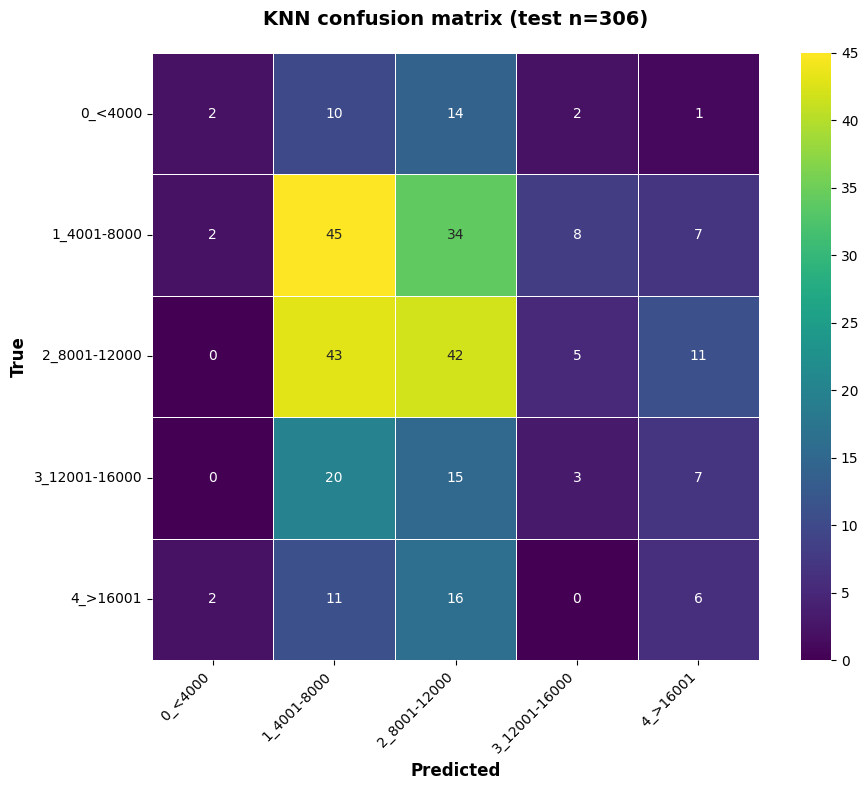


RANDOM FOREST

Classification Report:
               precision    recall  f1-score   support

      0_<4000     0.3000    0.1034    0.1538        29
  1_4001-8000     0.4297    0.5729    0.4911        96
 2_8001-12000     0.3932    0.4554    0.4220       101
3_12001-16000     0.2381    0.1111    0.1515        45
     4_>16001     0.2333    0.2000    0.2154        35

     accuracy                         0.3791       306
    macro avg     0.3189    0.2886    0.2868       306
 weighted avg     0.3547    0.3791    0.3549       306


Confusion Matrix (text):
               0_<4000  1_4001-8000  2_8001-12000  3_12001-16000  4_>16001
0_<4000              3           11            12              2         1
1_4001-8000          0           55            25              4        12
2_8001-12000         2           37            46             10         6
3_12001-16000        2           18            16              5         4
4_>16001             3            7            18             

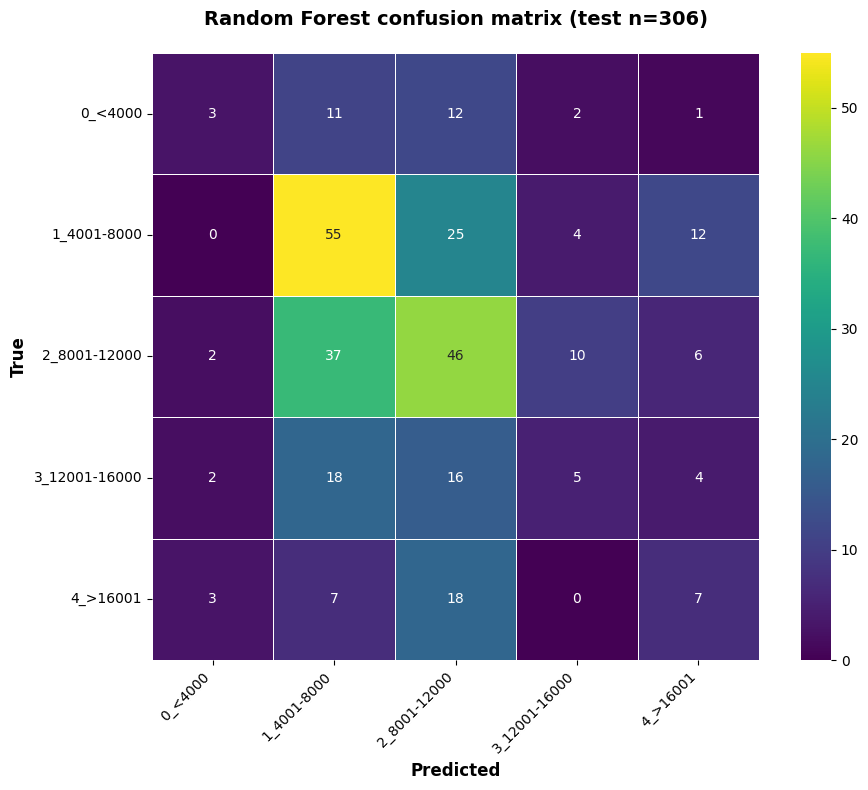


MODEL COMPARISON SUMMARY
        Model  Accuracy  F1 Macro  F1 Weighted
          KNN  0.320261  0.233401     0.295702
Random Forest  0.379085  0.286767     0.354853

✓ PIPELINE COMPLETED
  - Confusion matrices saved as PNG files
  - Models saved as PKL files


In [6]:
"""
Household income prediction from mobility data
Using KNN and Random Forest classifiers

Feature engineering covers the paper's spatiotemporal framework:
    (1) Spatial   – 1-order point, 2-order line, k-order motif
    (2) Temporal  – fragmentation, travel rhythm (q=3,8,24), rhythm entropy
    (3) Space-time integrated – k-ROG ratio, top-2 stay coords, unicity

All spatiotemporal features are computed on THREE slices:
    all / weekday / weekend   (suffix: _all, _wd, _we)

Classifier pipeline:
    - class_weight='balanced' for both models
    - f1_macro scoring
    - StandardScaler for KNN
    - Manual grid search for both models
"""

import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================
USE_3_CLASS        = False   # True  →  collapse into Low / Mid / High
# Motif frequency threshold: motifs appearing in < εm % of users are dropped
MOTIF_EPSILON_PCT  = 1.0     # percent

# ============================================================================
# 1. Data loading and preprocessing   (unchanged)
# ============================================================================

def load_data(trace_file='/data/baliu/python_code/data/sp_sampled2_v3_with_geocontext.csv',
              survey_file='/data/baliu/python_code/data/introSurvey_complete.csv'):
    trace_df  = pd.read_csv(trace_file)
    survey_df = pd.read_csv(survey_file)
    print(f"Trace data shape:  {trace_df.shape}")
    print(f"Survey data shape: {survey_df.shape}")
    return trace_df, survey_df


def categorize_income(income_value):
    """Map survey text labels → ordered income bins."""
    if pd.isna(income_value):
        return None
    s = str(income_value).strip().lower()
    if s == "prefer not to say":
        return None
    if "4 000 chf or less" in s or "4000 chf or less" in s:
        return "0_<4000"
    if "4 001 - 8 000 chf" in s:
        return "1_4001-8000"
    if "8 001 - 12 000 chf" in s:
        return "2_8001-12000"
    if "12 001 - 16 000 chf" in s:
        return "3_12001-16000"
    if "more than 16 000 chf" in s:
        return "4_>16001"
    return None


def collapse_to_3_class(cat):
    if cat in ("0_<4000", "1_4001-8000"):
        return "0_Low"
    if cat == "2_8001-12000":
        return "1_Mid"
    if cat in ("3_12001-16000", "4_>16001"):
        return "2_High"
    return None


def preprocess_survey_data(survey_df):
    print("\nPreprocessing survey data...")
    survey_df = survey_df.copy()
    survey_df['income_category'] = survey_df['income'].apply(categorize_income)
    survey_df = survey_df.dropna(subset=['income_category'])

    if USE_3_CLASS:
        survey_df['income_category'] = survey_df['income_category'].apply(collapse_to_3_class)
        survey_df = survey_df.dropna(subset=['income_category'])
        print("  → 3-class mode enabled (Low / Mid / High)")

    survey_df = survey_df[['participant_ID', 'income', 'income_category']]
    print("Income category distribution:")
    print(survey_df['income_category'].value_counts().sort_index())
    return survey_df


# ============================================================================
# 2. Geometry & haversine utilities   (unchanged)
# ============================================================================

def parse_geometry_to_coords(geometry_series):
    """
    Extract (lat, lon) from a geometry column.
    Handles  "POINT (lon lat)"  and  "(lat, lon)".
    """
    coords = pd.DataFrame(index=geometry_series.index, columns=['lat', 'lon'], dtype=float)
    for idx, val in geometry_series.items():
        if pd.isna(val):
            continue
        s = str(val).strip()
        if s.upper().startswith("POINT"):
            inner = s.split("(")[-1].rstrip(")")
            parts = inner.strip().split()
            if len(parts) == 2:
                coords.at[idx, 'lon'] = float(parts[0])
                coords.at[idx, 'lat'] = float(parts[1])
        else:
            cleaned = s.strip("()")
            parts   = cleaned.split(",")
            if len(parts) == 2:
                coords.at[idx, 'lat'] = float(parts[0].strip())
                coords.at[idx, 'lon'] = float(parts[1].strip())
    return coords


def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorised haversine → km."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


def shannon_entropy(counts):
    """Shannon entropy from an array / Series of counts."""
    p = np.asarray(counts, dtype=float)
    p = p[p > 0]
    p = p / p.sum()
    return -np.sum(p * np.log2(p + 1e-10))


# ============================================================================
# 3. Spatial features  –  1-order, 2-order, k-order motif
# ============================================================================

#────────────────────────────────────────────────────────────────

def _get_coords(group):
    """Return a clean (lat, lon) DataFrame from the group, NaN-free."""
    if 'geometry' in group.columns:
        coords = parse_geometry_to_coords(group['geometry'])
    elif 'lat' in group.columns and 'lon' in group.columns:
        coords = group[['lat', 'lon']].copy()
    else:
        return pd.DataFrame(columns=['lat', 'lon'])
    return coords.dropna(subset=['lat', 'lon'])


def _unique_stay_points(coords_df, decimals=3):
    """Round to `decimals` and return a Series of (lat_r, lon_r) keys."""
    r = coords_df.copy()
    r['lat_r'] = r['lat'].round(decimals)
    r['lon_r'] = r['lon'].round(decimals)
    return r[['lat_r', 'lon_r']].apply(tuple, axis=1)


# ── 1-order  (point-level) ─────────────────────────────────────────────────

def radius_of_gyration(coords_df):
    """ROG = sqrt( mean( haversine(pt, centroid)² ) )  in km."""
    if len(coords_df) < 2:
        return 0.0
    c_lat, c_lon = coords_df['lat'].mean(), coords_df['lon'].mean()
    d = haversine_km(coords_df['lat'].values, coords_df['lon'].values, c_lat, c_lon)
    return np.sqrt((d**2).mean())


def convex_hull_diameter(coords_df):
    """
    Diameter = max pairwise haversine distance among unique stay points.
    For efficiency cap at 200 unique points (random sample).
    """
    if len(coords_df) < 2:
        return 0.0
    pts = coords_df[['lat', 'lon']].drop_duplicates()
    if len(pts) > 200:
        pts = pts.sample(200, random_state=42)
    lats = pts['lat'].values
    lons = pts['lon'].values
    # vectorised pairwise
    lat_grid = np.abs(lats[:, None] - lats[None, :])   # quick pre-filter
    max_d = 0.0
    for i in range(len(lats)):
        d = haversine_km(lats[i], lons[i], lats, lons)
        candidate = d.max()
        if candidate > max_d:
            max_d = candidate
    return max_d


def ellipse_features(coords_df):
    """
    PCA on (lat, lon) → semi-axes e1 >= e2.
    Returns area (π·e1·e2), eccentricity, direction (deg).

    PCA is done in degree-space which is an approximation but consistent
    with the paper's formulation (they use Cartesian coordinates of stay
    points directly).
    """
    if len(coords_df) < 3:
        return {'trajectory_area': 0.0, 'eccentricity': 0.0, 'direction': 0.0}

    X = coords_df[['lat', 'lon']].values.astype(float)
    X_c = X - X.mean(axis=0)                      # centre
    cov = np.cov(X_c, rowvar=False)               # 2×2 covariance
    eigvals, eigvecs = np.linalg.eigh(cov)        # ascending order
    # semi-axis lengths = sqrt of eigenvalues  (std along each PC)
    e2 = np.sqrt(max(eigvals[0], 0.0))            # minor
    e1 = np.sqrt(max(eigvals[1], 0.0))            # major

    area = np.pi * e1 * e2                        # ellipse area (degree²)
    ecc  = np.sqrt(1.0 - (e2 / e1)**2) if e1 > 0 else 0.0

    # direction: angle of major eigenvector vs (1, 0)  → degrees
    major_vec = eigvecs[:, 1]                     # eigvec for largest eigval
    angle_rad = np.arccos(
        np.clip(np.dot(major_vec, [1, 0]) / (np.linalg.norm(major_vec) + 1e-30), -1, 1)
    )
    direction = np.degrees(angle_rad)

    return {'trajectory_area': area, 'eccentricity': ecc, 'direction': direction}


# ── 2-order  (line-level) ──────────────────────────────────────────────────

def travel_od_entropy(group, coords_df):
    """
    OD-pair entropy  −Σ p(s_i → s_{i+1}) log p(s_i → s_{i+1})
    using rounded stay-point keys as node identifiers.
    Requires the group to be sorted by time (caller's responsibility).
    """
    keys = _unique_stay_points(coords_df.reindex(group.index).dropna(subset=['lat', 'lon']))
    if len(keys) < 2:
        return 0.0
    # consecutive OD pairs
    od_pairs = list(zip(keys.values[:-1], keys.values[1:]))
    counts = Counter(od_pairs)
    return shannon_entropy(list(counts.values()))


# ── k-order  (motif) ──────────────────────────────────────────────────────

def _daily_motif_hash(day_group, coords_df):
    """
    Build the adjacency matrix for one day's trajectory, then return a
    canonical hash (sorted row-tuple of the adjacency matrix).

    Nodes = unique rounded stay-point keys visited that day.
    Directed edges = consecutive OD transitions.
    """
    keys = _unique_stay_points(coords_df.reindex(day_group.index).dropna(subset=['lat', 'lon']))
    if len(keys) < 2:
        return None
    unique_nodes = sorted(set(keys.values))
    node_idx     = {n: i for i, n in enumerate(unique_nodes)}
    n            = len(unique_nodes)
    adj          = np.zeros((n, n), dtype=int)
    for a, b in zip(keys.values[:-1], keys.values[1:]):
        adj[node_idx[a], node_idx[b]] += 1

    # Canonical form: sort rows lexicographically (simple isomorphism approx)
    row_tuples = tuple(sorted(tuple(row) for row in adj.tolist()))
    return row_tuples


def extract_motif_features(group, coords_df):
    """
    Per-user: count daily-motif types and return ratio features.
    Motifs that appear in < MOTIF_EPSILON_PCT % of the dataset are kept
    but may be pruned later in a global pass (see note in main).
    """
    if 'started_at' not in group.columns:
        return {'n_motif_types': 0}

    daily_hashes = []
    for _date, day_grp in group.sort_values('started_at').groupby(group['started_at'].dt.date):
        h = _daily_motif_hash(day_grp, coords_df)
        if h is not None:
            daily_hashes.append(h)

    if not daily_hashes:
        return {'n_motif_types': 0}

    motif_counts = Counter(daily_hashes)
    total_days   = len(daily_hashes)
    feats        = {'n_motif_types': len(motif_counts)}

    # top-3 motif ratios  (stable, low-cardinality representation)
    sorted_counts = sorted(motif_counts.values(), reverse=True)
    for rank, cnt in enumerate(sorted_counts[:3], start=1):
        feats[f'motif_top{rank}_ratio'] = cnt / total_days
    # pad missing ranks with 0
    for rank in range(len(sorted_counts) + 1, 4):
        feats[f'motif_top{rank}_ratio'] = 0.0

    return feats


# ── combined spatial dispatcher ────────────────────────────────────────────

def extract_spatial_features(group):
    """Return all spatial features (1-order + 2-order + motif)."""
    feats  = {}
    coords = _get_coords(group)

    # ── 2-order distance stats (unchanged) ──
    if 'distance' in group.columns:
        feats['total_distance']  = group['distance'].sum()
        feats['avg_distance']    = group['distance'].mean()
        feats['max_distance']    = group['distance'].max()
        feats['min_distance']    = group['distance'].min()
        feats['std_distance']    = group['distance'].std() if len(group) > 1 else 0.0
        feats['distance_range']  = feats['max_distance'] - feats['min_distance']

    if len(coords) == 0:
        feats.update({
            'unique_locations': 0, 'location_entropy': 0.0,
            'radius_of_gyration': 0.0, 'convex_hull_diameter': 0.0,
            'trajectory_area': 0.0, 'eccentricity': 0.0, 'direction': 0.0,
            'travel_od_entropy': 0.0,
            'n_motif_types': 0,
            'motif_top1_ratio': 0.0, 'motif_top2_ratio': 0.0, 'motif_top3_ratio': 0.0,
        })
        return feats

    # ── 1-order ──
    keys = _unique_stay_points(coords)
    feats['unique_locations']       = keys.nunique()
    feats['location_entropy']       = shannon_entropy(keys.value_counts().values)
    feats['radius_of_gyration']     = radius_of_gyration(coords)
    feats['convex_hull_diameter']   = convex_hull_diameter(coords)
    feats.update(ellipse_features(coords))

    # ── 2-order (OD entropy) ──
    feats['travel_od_entropy'] = travel_od_entropy(group, coords)

    # ── k-order motif ──
    feats.update(extract_motif_features(group, coords))

    return feats


# ============================================================================
# 4. Temporal features  –  fragmentation + travel rhythm
# ============================================================================

def _rhythm_vector(hours, q):
    """
    Compute q-bin travel-rhythm vector: p(t_1) … p(t_q).
    Bins are equal-width over [0, 24).
    Returns dict  { 'rhythm_q{q}_bin{b}': prob, … } and the entropy.
    """
    bin_width = 24.0 / q
    bins = np.floor(np.asarray(hours, dtype=float) / bin_width).astype(int)
    bins = np.clip(bins, 0, q - 1)          # edge case: hour == 24
    counts = np.bincount(bins, minlength=q)
    total  = counts.sum()
    probs  = counts / total if total > 0 else counts.astype(float)
    feats  = {f'rhythm_q{q}_bin{b}': float(probs[b]) for b in range(q)}
    feats[f'rhythm_q{q}_entropy'] = shannon_entropy(counts)
    return feats


def extract_temporal_features(group):
    feats = {}
    feats['total_trips'] = len(group)

    if 'started_at' not in group.columns:
        return feats

    group = group.copy()
    group['hour']        = group['started_at'].dt.hour
    group['day_of_week'] = group['started_at'].dt.dayofweek

    # ── peak / weekday ratio  (kept from original) ──
    feats['morning_peak_trips'] = ((group['hour'] >= 6)  & (group['hour'] <= 9)  & (group['day_of_week'] < 5)).sum()
    feats['evening_peak_trips'] = ((group['hour'] >= 16) & (group['hour'] <= 19) & (group['day_of_week'] < 5)).sum()
    feats['peak_trip_ratio']    = (feats['morning_peak_trips'] + feats['evening_peak_trips']) / max(feats['total_trips'], 1)

    feats['weekday_trips']      = (group['day_of_week'] < 5).sum()
    feats['weekend_trips']      = (group['day_of_week'] >= 5).sum()
    feats['weekend_trip_ratio'] = feats['weekend_trips'] / max(feats['total_trips'], 1)

    feats['unique_hours'] = group['hour'].nunique()
    feats['unique_days']  = group['started_at'].dt.date.nunique()

    # ── time-fragmentation degree  (NEW) ──
    # 1/N  Σ |dur_i − mean_dur|   normalised by mean so it is scale-free
    if 'started_at' in group.columns and 'finished_at' in group.columns:
        durations = (group['finished_at'] - group['started_at']).dt.total_seconds()
        durations = durations[durations > 0]
        if len(durations) > 1:
            mean_dur = durations.mean()
            feats['time_fragmentation'] = (np.abs(durations - mean_dur) / (mean_dur + 1e-10)).mean()
        else:
            feats['time_fragmentation'] = 0.0
    else:
        feats['time_fragmentation'] = 0.0

    # ── travel rhythm vectors  q = 3, 8, 24  (NEW) ──
    for q in [3, 8, 24]:
        feats.update(_rhythm_vector(group['hour'].values, q))

    return feats


# ============================================================================
# 5. Mode features  (unchanged)
# ============================================================================

def extract_mode_features(group):
    feats = {}
    if 'mode' in group.columns:
        mode_counts = group['mode'].value_counts()
        total       = len(group)
        for mode in group['mode'].unique():
            feats[f'mode_{mode}_count'] = mode_counts.get(mode, 0)
            feats[f'mode_{mode}_ratio'] = mode_counts.get(mode, 0) / total
        feats['mode_diversity']      = group['mode'].nunique()
        feats['mode_entropy']        = shannon_entropy(mode_counts.values)
        feats['dominant_mode_ratio'] = mode_counts.max() / total
    return feats


# ============================================================================
# 6. Space-time integrated features  –  k-ROG, top-2 coords, unicity
# ============================================================================

def _stay_durations(group, coords):
    """
    Return a DataFrame with columns [lat, lon, duration_s] indexed by
    unique stay point, duration = total seconds spent at that point.
    Requires started_at / finished_at.
    """
    if 'started_at' not in group.columns or 'finished_at' not in group.columns:
        return pd.DataFrame(columns=['lat', 'lon', 'duration_s'])

    tmp = group[['started_at', 'finished_at']].copy()
    tmp['duration_s'] = (tmp['finished_at'] - tmp['started_at']).dt.total_seconds().clip(lower=0)
    tmp = tmp.join(coords)                            # attach lat/lon
    tmp = tmp.dropna(subset=['lat', 'lon'])

    # round to stay-point key
    tmp['lat_r'] = tmp['lat'].round(3)
    tmp['lon_r'] = tmp['lon'].round(3)

    # aggregate total duration per unique stay point
    agg = (tmp.groupby(['lat_r', 'lon_r'])
           .agg(duration_s=('duration_s', 'sum'),
                lat=('lat', 'mean'),
                lon=('lon', 'mean'))
           .reset_index())
    return agg.sort_values('duration_s', ascending=False).reset_index(drop=True)


def extract_spacetime_features(group):
    """k-ROG ratio (k=2), top-2 stay-point coordinates, unicity."""
    feats = {}
    coords = _get_coords(group)

    if len(coords) == 0:
        feats.update({
            'k2_rog_ratio': 0.0,
            'top1_lat': 0.0, 'top1_lon': 0.0,
            'top2_lat': 0.0, 'top2_lon': 0.0,
        })
        return feats

    full_rog = radius_of_gyration(coords)

    stay_dur = _stay_durations(group, coords)

    # ── top-2 stay-point coordinates ──
    feats['top1_lat'] = float(stay_dur.iloc[0]['lat']) if len(stay_dur) > 0 else 0.0
    feats['top1_lon'] = float(stay_dur.iloc[0]['lon']) if len(stay_dur) > 0 else 0.0
    feats['top2_lat'] = float(stay_dur.iloc[1]['lat']) if len(stay_dur) > 1 else 0.0
    feats['top2_lon'] = float(stay_dur.iloc[1]['lon']) if len(stay_dur) > 1 else 0.0

    # ── k-ROG ratio  (k=2) ──
    # k-radius of gyration = ROG computed only on the top-k stay points
    if len(stay_dur) >= 2:
        top2 = stay_dur.head(2)[['lat', 'lon']]
        k2_rog = radius_of_gyration(top2)
        feats['k2_rog_ratio'] = k2_rog / (full_rog + 1e-10)
    else:
        feats['k2_rog_ratio'] = 0.0

    return feats


def compute_unicity(all_users_stay_dur, w_values=(2, 3, 4), resolutions=(200, 500)):
    """
    Population-level feature: computed AFTER per-user features are built.
    Unicity_w = (number of users whose top-w grid cells are unique) / total users.

    Parameters
    ----------
    all_users_stay_dur : dict  user_id → DataFrame with columns [lat, lon, duration_s]
    w_values           : top-w counts to try
    resolutions        : grid-cell sizes in metres  (approx: 1° lat ≈ 111 km)
    """
    feats_per_user = {}   # user_id → {unicity_200_w2: ..., ...}

    for res_m in resolutions:
        # grid-cell size in degrees (approximate, fine for Zürich latitude ≈ 47°)
        deg_per_m = 1.0 / 111_000                    # lat
        cell_size = res_m * deg_per_m                # degrees

        # map every user to their top-w cell tuples
        user_top_cells = {}                          # user_id → {w: frozenset}
        for uid, sdf in all_users_stay_dur.items():
            if len(sdf) == 0:
                continue
            sdf = sdf.copy()
            sdf['cell_lat'] = (sdf['lat'] // cell_size).astype(int)
            sdf['cell_lon'] = (sdf['lon'] // cell_size).astype(int)
            # already sorted descending by duration
            cells = list(zip(sdf['cell_lat'], sdf['cell_lon']))
            user_top_cells[uid] = cells

        total_users = len(user_top_cells)
        if total_users == 0:
            continue

        for w in w_values:
            # top-w cell sets (order doesn't matter → frozenset)
            top_w_sets = Counter()
            user_w_map = {}
            for uid, cells in user_top_cells.items():
                key = frozenset(cells[:w])
                top_w_sets[key] += 1
                user_w_map[uid] = key

            # unique = appears exactly once
            unique_keys = {k for k, v in top_w_sets.items() if v == 1}
            unicity = len(unique_keys) / total_users

            col = f'unicity_{res_m}m_w{w}'
            for uid in user_top_cells:
                feats_per_user.setdefault(uid, {})[col] = (
                    1.0 if user_w_map[uid] in unique_keys else 0.0
                )

    return feats_per_user, [f'unicity_{r}m_w{w}' for r in resolutions for w in w_values]


# ============================================================================
# 7. Per-user aggregation  –  all / weekday / weekend slices
# ============================================================================

def _slice_group(group):
    """Return (all, weekday, weekend) sub-DataFrames."""
    if 'started_at' in group.columns:
        dow = group['started_at'].dt.dayofweek
        return group, group[dow < 5], group[dow >= 5]
    return group, group, group   # fallback: no date info


def build_features_per_user(trace_df):
    """
    Build the full feature matrix.

    Structure
    ---------
    For each slice ∈ {all, wd, we} and each category
    (spatial / temporal / mode) we compute features and suffix the column.

    Space-time integrated features are computed on the 'all' slice only
    (they already combine space & time).

    Motif features are computed on the 'all' slice only (daily motifs
    need the full timeline).

    Unicity is a population-level feature computed after the per-user
    loop finishes.
    """
    print("\nBuilding features from mobility traces …")

    all_features       = []
    all_stay_dur       = {}      # user_id → stay-duration DataFrame  (for unicity)

    for user_id, grp in trace_df.groupby('user_id'):
        feat = {'user_id': user_id}
        grp_all, grp_wd, grp_we = _slice_group(grp)

        coords_all = _get_coords(grp_all)
        stay_dur   = _stay_durations(grp_all, coords_all)
        all_stay_dur[user_id] = stay_dur

        for label, sub in [('all', grp_all), ('wd', grp_wd), ('we', grp_we)]:
            suffix = f'_{label}'

            # ── temporal ──
            t_feats = extract_temporal_features(sub)
            feat.update({k + suffix: v for k, v in t_feats.items()})

            # ── spatial (1-order + 2-order distance stats) ──
            # motif is only on 'all' slice
            s_feats = extract_spatial_features(sub)
            # pull motif out; only keep for 'all'
            motif_keys = [k for k in s_feats if k.startswith('motif_') or k == 'n_motif_types']
            if label != 'all':
                for mk in motif_keys:
                    s_feats.pop(mk, None)
            feat.update({k + suffix: v for k, v in s_feats.items()})

            # ── mode ──
            m_feats = extract_mode_features(sub)
            feat.update({k + suffix: v for k, v in m_feats.items()})

        # ── derived daily rates  (all-slice only) ──
        unique_days = feat.get('unique_days_all', 1) or 1
        feat['trips_per_day']    = feat.get('total_trips_all', 0)    / unique_days
        feat['distance_per_day'] = feat.get('total_distance_all', 0) / unique_days

        # ── space-time integrated  (all-slice) ──
        feat.update(extract_spacetime_features(grp_all))

        all_features.append(feat)

    features_df = pd.DataFrame(all_features).fillna(0)
    print(f"  Feature matrix shape (before unicity): {features_df.shape}")

    # ── unicity  (population-level) ──
    print("  Computing unicity …")
    unicity_feats, unicity_cols = compute_unicity(all_stay_dur)
    unicity_df = pd.DataFrame(unicity_feats).T
    unicity_df.index.name = 'user_id'
    unicity_df = unicity_df.reindex(features_df['user_id']).fillna(0.0)
    unicity_df.index = features_df.index
    features_df = pd.concat([features_df, unicity_df], axis=1)

    print(f"  Final feature matrix shape: {features_df.shape}")
    print(f"  Number of features: {len(features_df.columns) - 1}")
    return features_df


# ============================================================================
# 8. Train / test prep
# ============================================================================

def prepare_train_test_data(features_df, survey_df, test_size=0.2, random_state=42):
    print("\nPreparing training and test data …")

    merged = features_df.merge(survey_df, left_on='user_id', right_on='participant_ID', how='inner')
    print(f"Merged shape: {merged.shape}   |   matched users: {len(merged)}")

    feature_cols = [c for c in merged.columns
                    if c not in ['user_id', 'participant_ID', 'income', 'income_category']]

    X = merged[feature_cols]
    y = merged['income_category']

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    print(f"\nFeature columns ({len(feature_cols)}):")
    print(feature_cols[:15], "…" if len(feature_cols) > 15 else "")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=test_size, random_state=random_state, stratify=y_enc
    )
    print(f"Train: {len(X_train)}   Test: {len(X_test)}")
    return X_train, X_test, y_train, y_test, le, feature_cols


# ============================================================================
# 9. KNN with 10 fold CV and hyperparameter tuning
# ============================================================================

def train_knn_model(X_train, y_train, X_test, y_test):
    print("\n" + "=" * 70)
    print("Training KNN model 10 fold cross validation ")
    print("=" * 70)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 19, 25],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    }

    total_combinations = (len(param_grid['n_neighbors']) * 
                         len(param_grid['weights']) * 
                         len(param_grid['metric']))
    
    print(f"Testing {total_combinations} hyperparameter combinations with 10-fold CV...")
    print(f"Total fits: {total_combinations * 10}")

    knn = KNeighborsClassifier()
    grid = GridSearchCV(knn, param_grid, cv=10, scoring='f1_macro', n_jobs=-1, verbose=0,return_train_score=True)
    print("\nGrid search (scoring = f1_macro) …")
    grid.fit(X_train_s, y_train)

    print(f"\n{'='*70}")
    print("VALIDATION RESULTS")
    print(f"{'='*70}")
    print(f"Best hyperparameters: {grid.best_params_}")
    print(f"Best CV f1_macro: {grid.best_score_:.4f} (±{grid.cv_results_['std_test_score'][grid.best_index_]:.4f})")

    # Show top 3
    cv_results = pd.DataFrame(grid.cv_results_)
    top_3 = cv_results.nsmallest(3, 'rank_test_score')[
        ['params', 'mean_test_score', 'std_test_score']
    ]
    print("\nTop 3 configurations:")
    for idx, row in top_3.iterrows():
        print(f"  {row['params']}")
        print(f"    → CV: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")


    best_knn      = grid.best_estimator_
    y_pred_train  = best_knn.predict(X_train_s)
    y_pred_test   = best_knn.predict(X_test_s)

    print("-" * 70)
    print(f"Training accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
    print(f"Test accuracy:     {accuracy_score(y_test,  y_pred_test):.4f}")

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy  = accuracy_score(y_test, y_pred_test)
    test_f1        = f1_score(y_test, y_pred_test, average='macro')

    print(f"\n{'='*70}")
    print("FINAL PERFORMANCE")
    print(f"{'='*70}")
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Test accuracy:     {test_accuracy:.4f}")
    print(f"Test f1_macro:     {test_f1:.4f}")
    print(f"CV f1_macro:       {grid.best_score_:.4f}")

    if train_accuracy - test_accuracy > 0.1:
        print(f"\n⚠️  Overfitting detected (gap: {train_accuracy - test_accuracy:.4f})")
    else:
        print(f"\n✓ Model generalizes well")

    return best_knn, scaler


# ============================================================================
# 10. Random Forest with 10 fold CV and hyperparameter tuning
# ============================================================================

def compute_sample_weights(y_train):
    classes, counts = np.unique(y_train, return_counts=True)
    n_samples       = len(y_train)
    n_classes       = len(classes)
    weight_map      = dict(zip(classes, n_samples / (n_classes * counts)))
    return np.array([weight_map[y] for y in y_train])


def train_random_forest_model(X_train, y_train, X_test, y_test, feature_cols):
    print("\n" + "=" * 70)
    print("Training Random Forest model with 10 fold cross validation")
    print("=" * 70)

    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }

    # train_accuracy = accuracy_score(y_train, y_pred_train)
    # test_accuracy  = accuracy_score(y_test, y_pred_test)
    # test_f1        = f1_score(y_test, y_pred_test, average='macro')

    # print(f"\n{'='*70}")
    # print("FINAL PERFORMANCE")
    # print(f"{'='*70}")
    # print(f"Training accuracy: {train_accuracy:.4f}")
    # print(f"Test accuracy:     {test_accuracy:.4f}")
    # print(f"Test f1_macro:     {test_f1:.4f}")
    # print(f"CV f1_macro:       {grid.best_score_:.4f}")

    # if train_accuracy - test_accuracy > 0.1:
    #     print(f"\n⚠️  Overfitting detected (gap: {train_accuracy - test_accuracy:.4f})")
    # else:
    #     print(f"\n✓ Model generalizes well")

    total_combinations = (len(param_grid['n_estimators']) * 
                         len(param_grid['max_depth']) * 
                         len(param_grid['min_samples_split']) * 
                         len(param_grid['min_samples_leaf']) * 
                         len(param_grid['max_features']))

    print(f"Testing {total_combinations} hyperparameter combinations with 10-fold CV...")
    print(f"Total fits: {total_combinations * 10}")
    print("⚠️  Note: This is computationally expensive!")

    rf = RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    grid = GridSearchCV(rf, param_grid, cv=10, scoring='f1_macro', n_jobs=-1, verbose=0, return_train_score=True)
    print("\nGrid search (scoring = f1_macro, class_weight = balanced) …")
    grid.fit(X_train, y_train)

    print(f"\n{'='*70}")
    print("VALIDATION RESULTS")
    print(f"{'='*70}")
    print(f"Best hyperparameters:")
    for param, value in grid.best_params_.items():
        print(f"  - {param}: {value}")
    print(f"\nBest CV f1_macro: {grid.best_score_:.4f} (±{grid.cv_results_['std_test_score'][grid.best_index_]:.4f})")

    # Show top 3
    cv_results = pd.DataFrame(grid.cv_results_)
    top_3 = cv_results.nsmallest(3, 'rank_test_score')[
        ['params', 'mean_test_score', 'std_test_score']
    ]
    print("\nTop 3 configurations:")
    for idx, row in top_3.iterrows():
        print(f"  Rank {int(cv_results.loc[idx, 'rank_test_score'])}: CV {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")

    best_rf = grid.best_estimator_

    # Prediction must come BEFORE calculating accuracy
    y_pred_train = best_rf.predict(X_train)
    y_pred_test  = best_rf.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy  = accuracy_score(y_test, y_pred_test)
    test_f1        = f1_score(y_test, y_pred_test, average='macro')

    print(f"\n{'='*70}")
    print("FINAL PERFORMANCE")
    print(f"{'='*70}")
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Test accuracy:     {test_accuracy:.4f}")
    print(f"Test f1_macro:     {test_f1:.4f}")
    print(f"CV f1_macro:       {grid.best_score_:.4f}")

    if train_accuracy > test_accuracy + 0.1:
        print(f"\n⚠️  Overfitting detected (gap: {train_accuracy - test_accuracy:.4f})")
    else:
        print(f"\n✓ Model generalizes well")

    importance = pd.DataFrame({
        'feature':    feature_cols,
        'importance': best_rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTop 15 feature importances:")
    print(importance.head(15).to_string(index=False))

    return best_rf, importance


# ============================================================================
# 11. Evaluation
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, labels, model_name, save_path=None):
    """
    Plot a confusion matrix heatmap similar to the provided image.
    
    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred : array-like
        Predicted labels
    labels : list
        List of label names
    model_name : str
        Name of the model (e.g., 'XGBoost', 'KNN', 'Random Forest')
    save_path : str, optional
        Path to save the figure
    """
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Create figure
    plt.figure(figsize=(10, 8))
    
    # Create heatmap
    sns.heatmap(
        cm, 
        annot=True,           # Show numbers in cells
        fmt='d',              # Integer format
        cmap='viridis',       # Color scheme (similar to your image)
        cbar=True,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor='white',
        square=True
    )
    
    # Add title with test sample count
    n_test = len(y_true)
    plt.title(f'{model_name} confusion matrix (test n={n_test})', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Labels
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('True', fontsize=12, fontweight='bold')
    
    # Rotate labels if needed
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Confusion matrix saved to: {save_path}")
    
    plt.show()
    plt.close()


def evaluate_models_with_plots(models_dict, X_test, y_test, label_encoder, save_dir='/data/baliu/python_code/data/'):
    """
    Evaluate models and generate confusion matrix plots.
    """
    print("\n" + "=" * 70)
    print("DETAILED MODEL COMPARISON WITH CONFUSION MATRICES")
    print("=" * 70)

    for name, info in models_dict.items():
        print(f"\n{'=' * 70}\n{name.upper()}\n{'=' * 70}")
        
        model  = info['model']
        X_proc = info['scaler'].transform(X_test) if 'scaler' in info else X_test
        y_pred = model.predict(X_proc)

        # Classification Report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred,
                                    target_names=label_encoder.classes_, digits=4))
        
        # Text-based Confusion Matrix
        print("\nConfusion Matrix (text):")
        cm = pd.DataFrame(confusion_matrix(y_test, y_pred),
                          index=label_encoder.classes_,
                          columns=label_encoder.classes_)
        print(cm)
        
        # Overall Accuracy
        acc = accuracy_score(y_test, y_pred)
        print(f"\nOverall Test Accuracy: {acc:.4f}")
        
        # Plot Confusion Matrix
        print(f"\nGenerating confusion matrix plot for {name}...")
        save_path = f"{save_dir}confusion_matrix_{name.replace(' ', '_').lower()}.png"
        plot_confusion_matrix(
            y_test, 
            y_pred, 
            label_encoder.classes_, 
            name,
            save_path=save_path
        )


def print_comparison(models_dict, X_test, y_test, label_encoder):
    """
    Print side-by-side model comparison.
    """
    print("\n" + "=" * 70)
    print("MODEL COMPARISON SUMMARY")
    print("=" * 70)

    rows = []
    for name, info in models_dict.items():
        model  = info['model']
        X_proc = info['scaler'].transform(X_test) if 'scaler' in info else X_test
        y_pred = model.predict(X_proc)

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        rows.append({
            'Model': name,
            'Accuracy': acc,
            'F1 Macro': f1_macro,
            'F1 Weighted': f1_weighted
        })

    comp_df = pd.DataFrame(rows)
    print(comp_df.to_string(index=False))


# ============================================================================
# Updated Main function
# ============================================================================

def main():
    print("="*70)
    print("HOUSEHOLD INCOME PREDICTION - KNN + RANDOM FOREST")
    print("Full spatiotemporal features with 10-fold CV")
    print("="*70)

    # 1. Load data
    trace_df, survey_df = load_data()

    # 2. Preprocess survey
    survey_df = preprocess_survey_data(survey_df)

    # 3. Parse datetime
    trace_df['started_at']  = pd.to_datetime(trace_df['started_at'],  errors='coerce')
    trace_df['finished_at'] = pd.to_datetime(trace_df['finished_at'], errors='coerce')
    trace_df = trace_df.dropna(subset=['started_at', 'finished_at'])

    # 4. Build features
    features_df = build_features_per_user(trace_df)

    # 5. Split train/test
    X_train, X_test, y_train, y_test, label_encoder, feature_cols = \
        prepare_train_test_data(features_df, survey_df)

    # 6. Train KNN with 10-fold CV
    knn_model, knn_scaler = train_knn_model(X_train, y_train, X_test, y_test)

    # 7. Train Random Forest with 10-fold CV
    rf_model, rf_importance = train_random_forest_model(
        X_train, y_train, X_test, y_test, feature_cols)

    # 8. Evaluate with confusion matrix plots
    models_dict = {
        'KNN':           {'model': knn_model,  'scaler': knn_scaler},
        'Random Forest': {'model': rf_model}
    }
    
    # ← Use new function with plots
    evaluate_models_with_plots(models_dict, X_test, y_test, label_encoder)
    
    # Print comparison table
    print_comparison(models_dict, X_test, y_test, label_encoder)

    # 9. Save models
    rf_importance.to_csv('/data/baliu/python_code/data/feature_importance_rf.csv', index=False)

    import pickle
    with open('/data/baliu/python_code/data/knn_model.pkl', 'wb') as f:
        pickle.dump({'model': knn_model, 'scaler': knn_scaler}, f)
    with open('/data/baliu/python_code/data/rf_model.pkl', 'wb') as f:
        pickle.dump(rf_model, f)
    with open('/data/baliu/python_code/data/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)

    print("\n" + "="*70)
    print("✓ PIPELINE COMPLETED")
    print("  - Confusion matrices saved as PNG files")
    print("  - Models saved as PKL files")
    print("="*70)


if __name__ == "__main__":
    main()

In [ ]:
import geopandas as gpd
import pandas as pd

FILE = '/data/baliu/python_code/data/arealstatistik_2056.gpkg'

# ── 1. column names + dtypes  (no geometry loaded) ──────────────────────
# fiona lets us read schema without touching geometry
import fiona
with fiona.open(FILE) as src:
    print("=== LAYER NAME ===")
    print(src.name)
    print("\n=== SCHEMA (field name : type) ===")
    for name, typ in src.schema['properties'].items():
        print(f"  {name:30s}  {typ}")
    print(f"\n=== CRS ===\n  {src.crs}")
    print(f"\n=== TOTAL FEATURES ===\n  {len(src)}")

# ── 2. first 5 rows as a plain DataFrame (geometry included but tiny) ───
gdf = gpd.read_file(FILE, rows=5)
print("\n=== FIRST 5 ROWS ===")
print(gdf.to_string())

print("\n=== GEOMETRY TYPE (sample) ===")
print(gdf.geometry.geom_type.value_counts().to_string())

print("\n=== GEOMETRY BOUNDS (sample) ===")
print(gdf.geometry.bounds.to_string())

# ── 3. value counts of every non-geometry column (first 5 rows only,
#        but gives us the flavour of what each column holds) ─────────────
print("\n=== SAMPLE VALUE COUNTS (5 rows) ===")
for col in gdf.columns:
    if col == gdf.geometry.name:
        continue
    print(f"\n  [{col}]")
    print(f"    {gdf[col].value_counts().to_string()}")

    # AS_04 umschwung von ein - und zweifamilienhausern
    # AS_17 strassen, wege
    # LC_27. 
    # LC_6
    # LU_46

=== LAYER NAME ===
arealstatistik_current

=== SCHEMA (field name : type) ===
  RELI                            int32
  E_COORD                         int32
  N_COORD                         int32
  GMDE_ID                         int32
  GMDE_HISTID                     int32
  FJ                              int32
  METHOD25                        int32
  REVISION25                      int32
  AS_72                           int32
  AS_27                           int32
  AS_17                           int32
  AS_4                            int32
  LC_27                           int32
  LC_6                            int32
  LU_46                           int32
  LU_10                           int32
  LU_4                            int32

=== CRS ===
  EPSG:2056

=== TOTAL FEATURES ===
  4129071

=== FIRST 5 ROWS ===
       RELI  E_COORD  N_COORD  GMDE_ID  GMDE_HISTID    FJ  METHOD25  REVISION25  AS_72  AS_27  AS_17  AS_4  LC_27  LC_6  LU_46  LU_10  LU_4                 geome

## 3. Predict Sociodemographics using "gpt-oss-20b" model based on the prompts we just generated 

In [40]:
import ollama

models = ollama.list()
print(models)

models=[Model(model='gpt-oss:20b', modified_at=datetime.datetime(2025, 11, 9, 20, 40, 9, 692297, tzinfo=TzInfo(3600)), digest='17052f91a42e97930aa6e28a6c6c06a983e6a58dbb00434885a0cf5313e376f7', size=13793441244, details=ModelDetails(parent_model='', format='gguf', family='gptoss', families=['gptoss'], parameter_size='20.9B', quantization_level='MXFP4'))]


In [41]:
import os, json, re, subprocess, sys
import torch, requests
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    p = torch.cuda.get_device_properties(0)
    print("VRAM (GB):", round(p.total_memory/1024**3, 2))

# Check ollama is reachable
r = requests.get("http://127.0.0.1:11434/api/tags", timeout=3)
print("Ollama OK. Models:", [m["name"] for m in r.json().get("models",[])])

CUDA available: True
GPU: NVIDIA L4
VRAM (GB): 22.06
Ollama OK. Models: ['gpt-oss:20b']


read prompts from text version

In [ ]:
import json
import time
import os
import re
import sys
import signal
from pathlib import Path
import ollama
import pandas as pd

# --------------------------------------
# Config
# --------------------------------------
os.environ["OLLAMA_HOST"] = "http://127.0.0.1:11434"
client = ollama.Client(host=os.environ["OLLAMA_HOST"])


# prompts_v3_1week_income_29Jan2026_clean  prompts_v3_1week_income_29Jan2026
PROMPT_TXT = Path("/data/baliu/python_code/data/prompts_v3_1week_income_29Jan2026_clean.txt")
PRED_JSON  = Path("/data/baliu/python_code/data/preds_v3_1week_income_29Jan2026.jsonl")
PRED_CSV   = Path("/data/baliu/python_code/data/preds_v3_1week_income_29Jan2026.csv")

MODEL_NAME = "gpt-oss:20b"
SEP = "=" * 80

# ---- safety knobs ----
MAX_PROMPT_CHARS = 20_000     # prompt length guard
TIMEOUT_SEC      = 600        # generation timeout per user
COOLDOWN_EVERY   = 20         # periodic cooldown interval
COOLDOWN_SEC     = 10

# --------------------------------------
# Timeout handling (linux)
# --------------------------------------
class TimeoutError(Exception):
    pass

def timeout_handler(signum, frame):
    raise TimeoutError("Generation timed out")

signal.signal(signal.SIGALRM, timeout_handler)

# --------------------------------------
# load done users
# --------------------------------------
def load_done_users(path: Path) -> set:
    done = set()
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                try:
                    obj = json.loads(line)
                    if "user_id" in obj:
                        done.add(obj["user_id"])
                except Exception:
                    continue
    return done

# --------------------------------------
# Load prompts
# --------------------------------------
with open(PROMPT_TXT, "r", encoding="utf-8") as f:
    raw = f.read()

prompts = [p.strip() for p in raw.split(SEP) if p.strip()]
print(f"📦 Loaded {len(prompts)} prompts")

# --------------------------------------
# Load checkpoint once
# --------------------------------------
done_users = load_done_users(PRED_JSON)
print(f"🔁 Found {len(done_users)} completed users")

preds = []

# --------------------------------------
# Main loop
# --------------------------------------
try:
    for i, prompt in enumerate(prompts, 1):

        m = re.search(r"User:\s*(\S+)", prompt)
        if not m:
            print("⚠️ Cannot find user_id, skipping")
            continue

        user_id = m.group(1)

        if user_id in done_users:
            print(f"⏭️ Skipping {user_id}")
            continue

        print(f"\n🔮 [{i}/{len(prompts)}] Predicting {user_id}")

        # ---- prompt length guard ----
        if len(prompt) > MAX_PROMPT_CHARS:
            print(f"⚠️ Prompt too long ({len(prompt)} chars), skip {user_id}")
            continue

        try:
            print("💓 Heartbeat: sending to model")
            start_t = time.time()

            signal.alarm(TIMEOUT_SEC)

            resp = client.generate(
                model=MODEL_NAME,
                prompt=prompt,
                options={
                    "temperature": 0.1,
                    "num_ctx": 2048
                }
            )

            signal.alarm(0)

            dt = time.time() - start_t
            print(f"⏱️ Model returned in {dt:.1f}s")

            content = resp.get("response", "").strip()

            try:
                result = json.loads(content)
            except Exception:
                result = {
                    "raw_output": content,
                    "error": "json_parse_failed"
                }

            result["user_id"] = user_id
            preds.append(result)

            with open(PRED_JSON, "a", encoding="utf-8") as f:
                f.write(json.dumps(result, ensure_ascii=False) + "\n")
                f.flush()
                os.fsync(f.fileno())

            done_users.add(user_id)
            print(f"✅ Completed {user_id}")

        except TimeoutError:
            print(f"⏰ Timeout for {user_id}, skipping")
            continue

        except Exception as e:
            print(f" Error for {user_id}: {e}")
            time.sleep(2)
            continue            

        # ---- periodic cooldown ----
        if i % COOLDOWN_EVERY == 0:
            print("🧹 Cooling down GPU / Ollama...")
            time.sleep(COOLDOWN_SEC)

except KeyboardInterrupt:
    print("\n🛑 Interrupted by user. Progress saved safely.")
    sys.exit(0)

# --------------------------------------
# Save CSV snapshot
# --------------------------------------
if PRED_JSON.exists():
    df = pd.read_json(PRED_JSON, lines=True)
    df.to_csv(PRED_CSV, index=False)
    print(f"\n🎉 Saved {len(preds)} new predictions → {PRED_CSV}")
else:
    print("⚠️ No new predictions generated")


📦 Loaded 2102 prompts
🔁 Found 692 completed users
⏭️ Skipping AAGAF
⏭️ Skipping AAINS
⏭️ Skipping AAQME
⏭️ Skipping AARWP
⏭️ Skipping ABARC
⏭️ Skipping ABECR
⏭️ Skipping ABENL
⏭️ Skipping ABISR
⏭️ Skipping ABLPH
⏭️ Skipping ACSUF
⏭️ Skipping ACWVM
⏭️ Skipping ADCMH
⏭️ Skipping AEBWY
⏭️ Skipping AEGHJ
⏭️ Skipping AEWVV
⏭️ Skipping AFNCT
⏭️ Skipping AFUVG
⏭️ Skipping AGHUY
⏭️ Skipping AHTYK
⏭️ Skipping AJJJR
⏭️ Skipping AJJNX
⏭️ Skipping AJKBY
⏭️ Skipping AJQGV
⏭️ Skipping AKGPG
⏭️ Skipping AKMIL
⏭️ Skipping AKOZE
⏭️ Skipping AKQKS
⏭️ Skipping ALKPX
⏭️ Skipping ALSMT
⏭️ Skipping AMGUM
⏭️ Skipping AMGZL
⏭️ Skipping AMYMD
⏭️ Skipping ANEFF
⏭️ Skipping ANMKC
⏭️ Skipping ANQHI
⏭️ Skipping AOVGU
⏭️ Skipping AOVLF
⏭️ Skipping APKPN
⏭️ Skipping APWYR
⏭️ Skipping AQFEA
⏭️ Skipping AQQGE
⏭️ Skipping AQREK
⏭️ Skipping ARFNG
⏭️ Skipping ARMZF
⏭️ Skipping ARZDI
⏭️ Skipping ASUKL
⏭️ Skipping ASXOD
⏭️ Skipping ATBSI
⏭️ Skipping ATCBP
⏭️ Skipping ATEAN
⏭️ Skipping ATKDY
⏭️ Skipping AUXLS
⏭️ Skipping AW

SystemExit: 0

/home/baliu/.venvs/gptoss-env/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


: 

## Evaluation

In [ ]:
import pandas as pd
import json
import re
from pathlib import Path

# --------------------------------------
# Load raw predictions
# --------------------------------------
raw_path = Path("/data/baliu/python_code/data/preds_v3_1week_income_29Jan2026.jsonl")

df = pd.read_json(raw_path, lines=True)

print(f"Loaded raw predictions: {len(df)} rows")

# --------------------------------------
# Income extraction functions
# --------------------------------------
def extract_from_text(text):
    if pd.isna(text):
        return None

    try:
        data = json.loads(text)
        income_level = data.get("income_level", "")
        if income_level:
            if income_level in [">=16000", ">=16001", "16001+", "16000+"]:
                return ">16000"
            return income_level
    except Exception:
        pass

    text = str(text).lower()

    norm = (
        text.lower()
            .replace("chf", "")
            .replace("\u202f", "")
            .replace("\xa0", "")
            .replace(",", "")
    )

    if re.search(
        r'(>=\s*16000|>=\s*16001|16001\+|16000\+|'
        r'more\s+than\s+16000|above\s+16000|at\s+least\s+16000)',
        norm
    ):
        return ">16000"

    m = re.search(r'between\s*(\d{3,5})\s*and\s*(\d{3,5})', norm)
    if m:
        return map_income_bin(int(m.group(1)), int(m.group(2)))

    m = re.search(r'(\d{1,2}[,.]?\d{3})\s*[-–]\s*(\d{1,2}[,.]?\d{3})', norm)

    if m:
        return map_income_bin(int(m.group(1)), int(m.group(2)))

    for g in ["<4000", "4001-8000", "8001-12000", "12001-16000", ">16000"]:
        if g in text:
            return g

    return None

def map_income_bin(low, high):
    if high <= 4000:
        return "<4000"
    elif low >= 4001 and high <= 8000:
        return "4001-8000"
    elif low >= 8001 and high <= 12000:
        return "8001-12000"
    elif low >= 12001 and high <= 16000:
        return "12001-16000"
    elif high >= 16000:
        return ">16000"
    else:
        return None

# --------------------------------------
# Apply extraction
# --------------------------------------
TEXT_COL = "raw_output"
df["income_level"] = df[TEXT_COL].apply(extract_from_text)

print(df.columns.tolist())
print(df.head(3))


print(df["income_level"].value_counts(dropna=False))

# --------------------------------------
# Save cleaned CSV
# --------------------------------------
#out_path = Path("/data/baliu/python_code/data/preds_v3_1week_income_29Jan2026_clean.jsonl")

df_clean = (
    df[["user_id", "income_level"]]
    .drop_duplicates(subset=["user_id"])
    .sort_values("user_id")
    .reset_index(drop=True)
)

out_path = Path("/data/baliu/python_code/data/preds_v3_1week_income_29Jan2026_clean.jsonl")
df_clean.to_json(out_path, orient="records", lines=True)
out_path = Path("/data/baliu/python_code/data/preds_v3_1week_income_29Jan2026_clean.csv")
df_clean.to_csv(out_path, index=False)


df_clean.to_csv(out_path, index=False)

print(f"✅ Clean predictions saved to: {out_path}")
print(f"📊 Rows: {len(df_clean)}")
print(df_clean.head(20))


Loaded raw predictions: 414 rows
['raw_output', 'error', 'user_id', 'prediction', 'explanation', 'income_level']
                                          raw_output              error  \
0  The user’s mobility pattern shows a high level...  json_parse_failed   
1  The user’s mobility pattern shows a typical co...  json_parse_failed   
2  The user’s mobility pattern shows a typical su...  json_parse_failed   

  user_id prediction explanation income_level  
0   AAGAF        NaN         NaN  12001-16000  
1   AAINS        NaN         NaN    4001-8000  
2   AAQME        NaN         NaN   8001-12000  
income_level
8001-12000     192
12001-16000     82
>16000          47
None            47
4001-8000       37
<4000            9
Name: count, dtype: int64
✅ Clean predictions saved to: /data/baliu/python_code/data/preds_v3_1week_income_29Jan2026_clean.csv
📊 Rows: 414
   user_id income_level
0    AAGAF  12001-16000
1    AAINS    4001-8000
2    AAQME   8001-12000
3    AARWP  12001-16000
4    ABA

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

# --------------------------------------
# File paths
# --------------------------------------
gt_path = Path("/data/baliu/python_code/data/gt_with_age_household_income_level.csv")
pred_path = Path("/data/baliu/python_code/data/preds_v3_1week_income_29Jan2026_clean.csv")

# --------------------------------------
# Load data
# --------------------------------------
gt = pd.read_csv(gt_path)
pred = pd.read_csv(pred_path)

print(f"Loaded ground truth ({len(gt)} rows)")
print(f"Loaded predictions  ({len(pred)} rows)")

# --------------------------------------
# Select & align columns
# --------------------------------------
gt = gt[["user_id", "age_group", "household_size_group", "income_level"]]
# pred = pred[["user_id", "age_group", "household_sizes", "income_level"]]
pred = pred[["user_id", "income_level"]]

# --------------------------------------
# Normalize household size
# --------------------------------------
# def normalize_household_size(x):
#     if pd.isna(x):
#         return np.nan
#     try:
#         x = float(x)
#     except Exception:
#         return np.nan

#     if x >= 5:
#         return "5+"
#     else:
#         return str(int(x))

# gt["hh_norm"] = gt["household_size_group"].apply(normalize_household_size)
# pred["hh_norm"] = pred["household_sizes"].apply(normalize_household_size)

# --------------------------------------
# Merge GT and predictions
# --------------------------------------
merged = pd.merge(
    gt,
    pred,
    on="user_id",
    suffixes=("_true", "_pred")
)

print(f"Merged {len(merged)} users")

# --------------------------------------
# Masks for valid evaluation samples
# --------------------------------------
# age_mask = (
#     merged["age_group_true"].notna() &
#     merged["age_group_pred"].notna()
# )

# hh_mask = (
#     merged["hh_norm_true"].notna() &
#     merged["hh_norm_pred"].notna()
# )

income_mask = (
    merged["income_level_true"].notna() &
    merged["income_level_pred"].notna() &
    (merged["income_level_true"].str.lower() != "prefer not to say")
)

print("\nEvaluation sample sizes:")
# print(f"Age:        {age_mask.sum()}")
# print(f"Household:  {hh_mask.sum()}")
print(f"Income:     {income_mask.sum()}")

# --------------------------------------
# Accuracy computation
# # --------------------------------------
# age_acc = (
#     merged.loc[age_mask, "age_group_true"]
#     == merged.loc[age_mask, "age_group_pred"]
# ).mean()

# household_acc = (
#     merged.loc[hh_mask, "hh_norm_true"]
#     == merged.loc[hh_mask, "hh_norm_pred"]
# ).mean()

income_acc = (
    merged.loc[income_mask, "income_level_true"]
    == merged.loc[income_mask, "income_level_pred"]
).mean()

# --------------------------------------
# Majority-class baselines (for context)
# --------------------------------------
def majority_baseline(y_true):
    majority = y_true.value_counts().idxmax()
    return (y_true == majority).mean()

# age_baseline = majority_baseline(
#     merged.loc[age_mask, "age_group_true"]
# )

# hh_baseline = majority_baseline(
#     merged.loc[hh_mask, "hh_norm_true"]
#)

# income_baseline = majority_baseline(
#     merged.loc[income_mask, "income_level_true"]
# )

# --------------------------------------
# Output results
# --------------------------------------
print("\n📊 Accuracy Results:")
# print(f"Age group accuracy:        {age_acc:.3f} (baseline {age_baseline:.3f})")
# print(f"Household size accuracy:  {household_acc:.3f} (baseline {hh_baseline:.3f})")
#print(f"Income level accuracy:    {income_acc:.3f} (baseline {income_baseline:.3f})")
print(f"Income level accuracy:    {income_acc:.3f} ")
# --------------------------------------
# Save merged comparison tables
# --------------------------------------
output_path = Path("/data/baliu/python_code/data/merged_comparison_v5_final.csv")
merged.to_csv(output_path, index=False, encoding="utf-8")

filtered_income_path = Path(
    "/data/baliu/python_code/data/comparison_income_eval_v5_final.csv"
)
merged.loc[income_mask].to_csv(
    filtered_income_path, index=False, encoding="utf-8"
)

print(f"\nDetailed comparison saved to: {output_path}")
print(f"Income-eval subset saved to: {filtered_income_path}")

# --------------------------------------
# (Optional) Confusion matrices
# --------------------------------------
# age_cm = pd.crosstab(
#     merged.loc[age_mask, "age_group_true"],
#     merged.loc[age_mask, "age_group_pred"],
#     normalize="index"
# )

# age_cm_path = Path(
#     "/data/baliu/python_code/data/age_confusion_matrix_v4_final.csv"
# )
# age_cm.to_csv(age_cm_path)

# print(f"Age confusion matrix saved to: {age_cm_path}")

# ---- Confusion matrix (income) ----
income_cm = pd.crosstab(
    merged.loc[income_mask, "income_level_true"],
    merged.loc[income_mask, "income_level_pred"]
    #normalize="index"
)

print("\nIncome confusion matrix (counts):")
print(income_cm)

income_cm = pd.crosstab(
    merged.loc[income_mask, "income_level_true"],
    merged.loc[income_mask, "income_level_pred"],
    normalize="index"
)

print("\nIncome confusion matrix (row-normalized):")
print(income_cm)

/tmp/ipykernel_930041/1873157119.py:14: DtypeWarning: Columns (4,6,7,8,9,10,11,12,13,15,17,18,19,20,21,22,23,28,29,30,31,32,33,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,113,114,115,116,117,118,119,120,121,122,123) have mixed types. Specify dtype option on import or set low_memory=False.
  gt = pd.read_csv(gt_path)


Loaded ground truth (90909 rows)
Loaded predictions  (414 rows)
Merged 414 users

Evaluation sample sizes:
Income:     328

📊 Accuracy Results:
Income level accuracy:    0.271 

Detailed comparison saved to: /data/baliu/python_code/data/merged_comparison_v5_final.csv
Income-eval subset saved to: /data/baliu/python_code/data/comparison_income_eval_v5_final.csv

Income confusion matrix (counts):
income_level_pred  12001-16000  4001-8000  8001-12000  <4000  >16000
income_level_true                                                   
12001-16000                 15          6          25      0       4
4001-8000                   23         15          51      2      19
8001-12000                  17          8          54      5      13
<4000                        4          3          21      0       3
>16000                      12          1          21      1       5

Income confusion matrix (row-normalized):
income_level_pred  12001-16000  4001-8000  8001-12000     <4000    >16000
inc